# $\nu_{\tau}$ Investigation in the Dune Collaboration for Advanced Particle Physics Laboratory 2026 - NN Training
Author: Grzegorz Jędrzejowski \
Supervision: prof. Katarzyna Grzelak


## Global Variables

In [ ]:
train = 1 #1 for train, 0 for ensemble/load mode


scaling_factor = 1.0 #0.0025 is prototype size, 1 is for full sets
training_size = int(1800000 * scaling_factor) #1.8mln is full expected training set with space for val
val_size = int(500000 * scaling_factor) #500k 

track = 0   #deploy commet tracking
save = 1    #save checkpoints when training and enable early stopping
full_plot = 1 #plot additional plots, that are useful for consistency checks


# Includes

In [2]:
import os, sys, importlib
my_home = '/scratch1/gjedrzej/Lab'
os.chdir(my_home) #GJ path
sys.path.append(os.path.join(os.getcwd(), "python"))

In [3]:
requirements_path = os.path.join(my_home, 'requirements.txt')

%pip install --upgrade pip #Pip 21.3+ is required
%pip install -r {requirements_path}

#you might need to restart the kernel after installing requirements

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import comet_ml
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np

2026-05-25 13:03:48.335893: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-25 13:03:48.339285: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-25 13:03:48.382526: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-25 13:03:49.272468: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/scratch1/gjedrzej/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Seeds

In [5]:
np.random.seed(42)
tf.random.set_seed(42)
#preprocess has also fixed seed

## Custom libraries

In [6]:
import analysis.scripts.convert_full_nodebug as kg
importlib.reload(kg)

import analysis.scripts.convert_skwarek as sk
importlib.reload(sk)

import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

import analysis.scripts.ml_functions as ml
importlib.reload(ml)

import analysis.scripts.system_functions as sf
importlib.reload(sf)

import analysis.scripts.preprocess_functions as prf
importlib.reload(prf)


output_dir = 'analysis/processedData'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"Created directory: {output_dir}")

/scratch1/gjedrzej/.local/lib/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/scratch1/gjedrzej/.local/lib/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


## CSV Example Processing

In [7]:
process_csv = 0
if process_csv:
    #a file generated by a Generators/generateEventsAll0530_Val.sh and converted using convertEvents.sh
    FilePath_val = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_interactions_val.gtrac.root"
    output_path_val = os.path.join(output_dir, 'data_all_tau_val.csv')
    kg.extract_data(FilePath_val, output_path_val) #this wouldn't work for large datasets as RAM would overflow. For larger datasets manual conversion with que-like system was implemented (analysis/scripts/manual_csv_converter.py).

# File Paths

In [ ]:
output_path_train_val = os.path.join(output_dir, 'data_train_preprocessed.csv') #17 mln cc, nc. generated seperately and concatenated, it has calculated features and removed old data. It requires nan handling and CC/NC transformation to integers. 

output_path_test = os.path.join(output_dir, 'data_all_tau_train.csv') #5 mln cc, nc on default, it has calculated features and removed old data. It requires nan handling and CC/NC transformation to integers. 


## Preprocess Train, Val, Test
Features (12): <br>
               Charged Pions - Multiplicity, Leading (max momentum) Momentum, Leading Tranverse Momentum, Leading Cosine Theta <br>
               Neutral Pions - Multiplicity, Leading (max momentum) Momentum, Leading Tranverse Momentum, Leading Cosine Theta <br>
               Charged Particles - Multiplicity, Leading (max momentum) Momentum, Leading Tranverse Momentum, Leading Cosine Theta <br>
Labels (1): CCNC
Metadata (1): Interaction Type (QES, DIS, MEC, RES)

In [ ]:
#Train - the csv is already preprocessed to some degree for computing efficiency (get_feature_data, clean_particle_data, prepare_combined_pool)
import analysis.scripts.preprocess_functions as prf
importlib.reload(prf)


#singal & background load and transform labels 
df_raw_training_data = pd.read_csv(output_path_train_val)
df_raw_training_data = prf.transform_ccnc(df_raw_training_data) #'CC' -> 1, 'NC' -> 0 
df_raw_training_data = prf.fill_nans(df_raw_training_data) #replace nans with 0s

df_legacy = df_raw_training_data #pointer for it to work with the same set up as demo did

#finish preprocessing train
df_balanced_train = df_raw_training_data.copy()
df_balanced_train = prf.filter_int_types(df_balanced_train, ['COH', 'NuEEL']) #very rare classes

#17 mln is high statistics so low stat. noise, hence its used for val as well, but not test for no leaks 
df_balanced_train, df_unbalanced_val, _ = prf.get_physics_informed_split(df_balanced_train, total_train_size=training_size, total_val_size=val_size, total_test_size=0)


Removed 68293 rows with IntTypes: ['COH', 'NuEEL']
Split Complete. Overlap Checks:
  - Train/Val shared events:  1695

[Validation Set Physics Profile]
CC/NC Ratio: {0: 0.7029336234689878, 1: 0.29706637653101226}
Interaction Type Ratios:
IntType
DIS    0.437934
RES    0.328999
QES    0.198576
MEC    0.034492
Name: proportion, dtype: float64


In [11]:
#Test - this dataset is not preprocessed

df_unbalanced_test = pd.read_csv(output_path_test)
#calculate features 
#singal & background load and transform labels 
df_unbalanced_test = prf.transform_ccnc(df_unbalanced_test) #'CC' -> 1, 'NC' -> 0 
df_unbalanced_test = prf.fill_nans(df_unbalanced_test) #replace nans with 0s


#finish preprocessing train - initially the rare classes were excluded
# df_unbalanced_test = prf.filter_int_types(df_unbalanced_test, ['COH', 'NuEEL'])

df_unbalanced_test = df_unbalanced_test.sample(frac=1, random_state=42).reset_index(drop=True)

## Plotting Sets Proportions

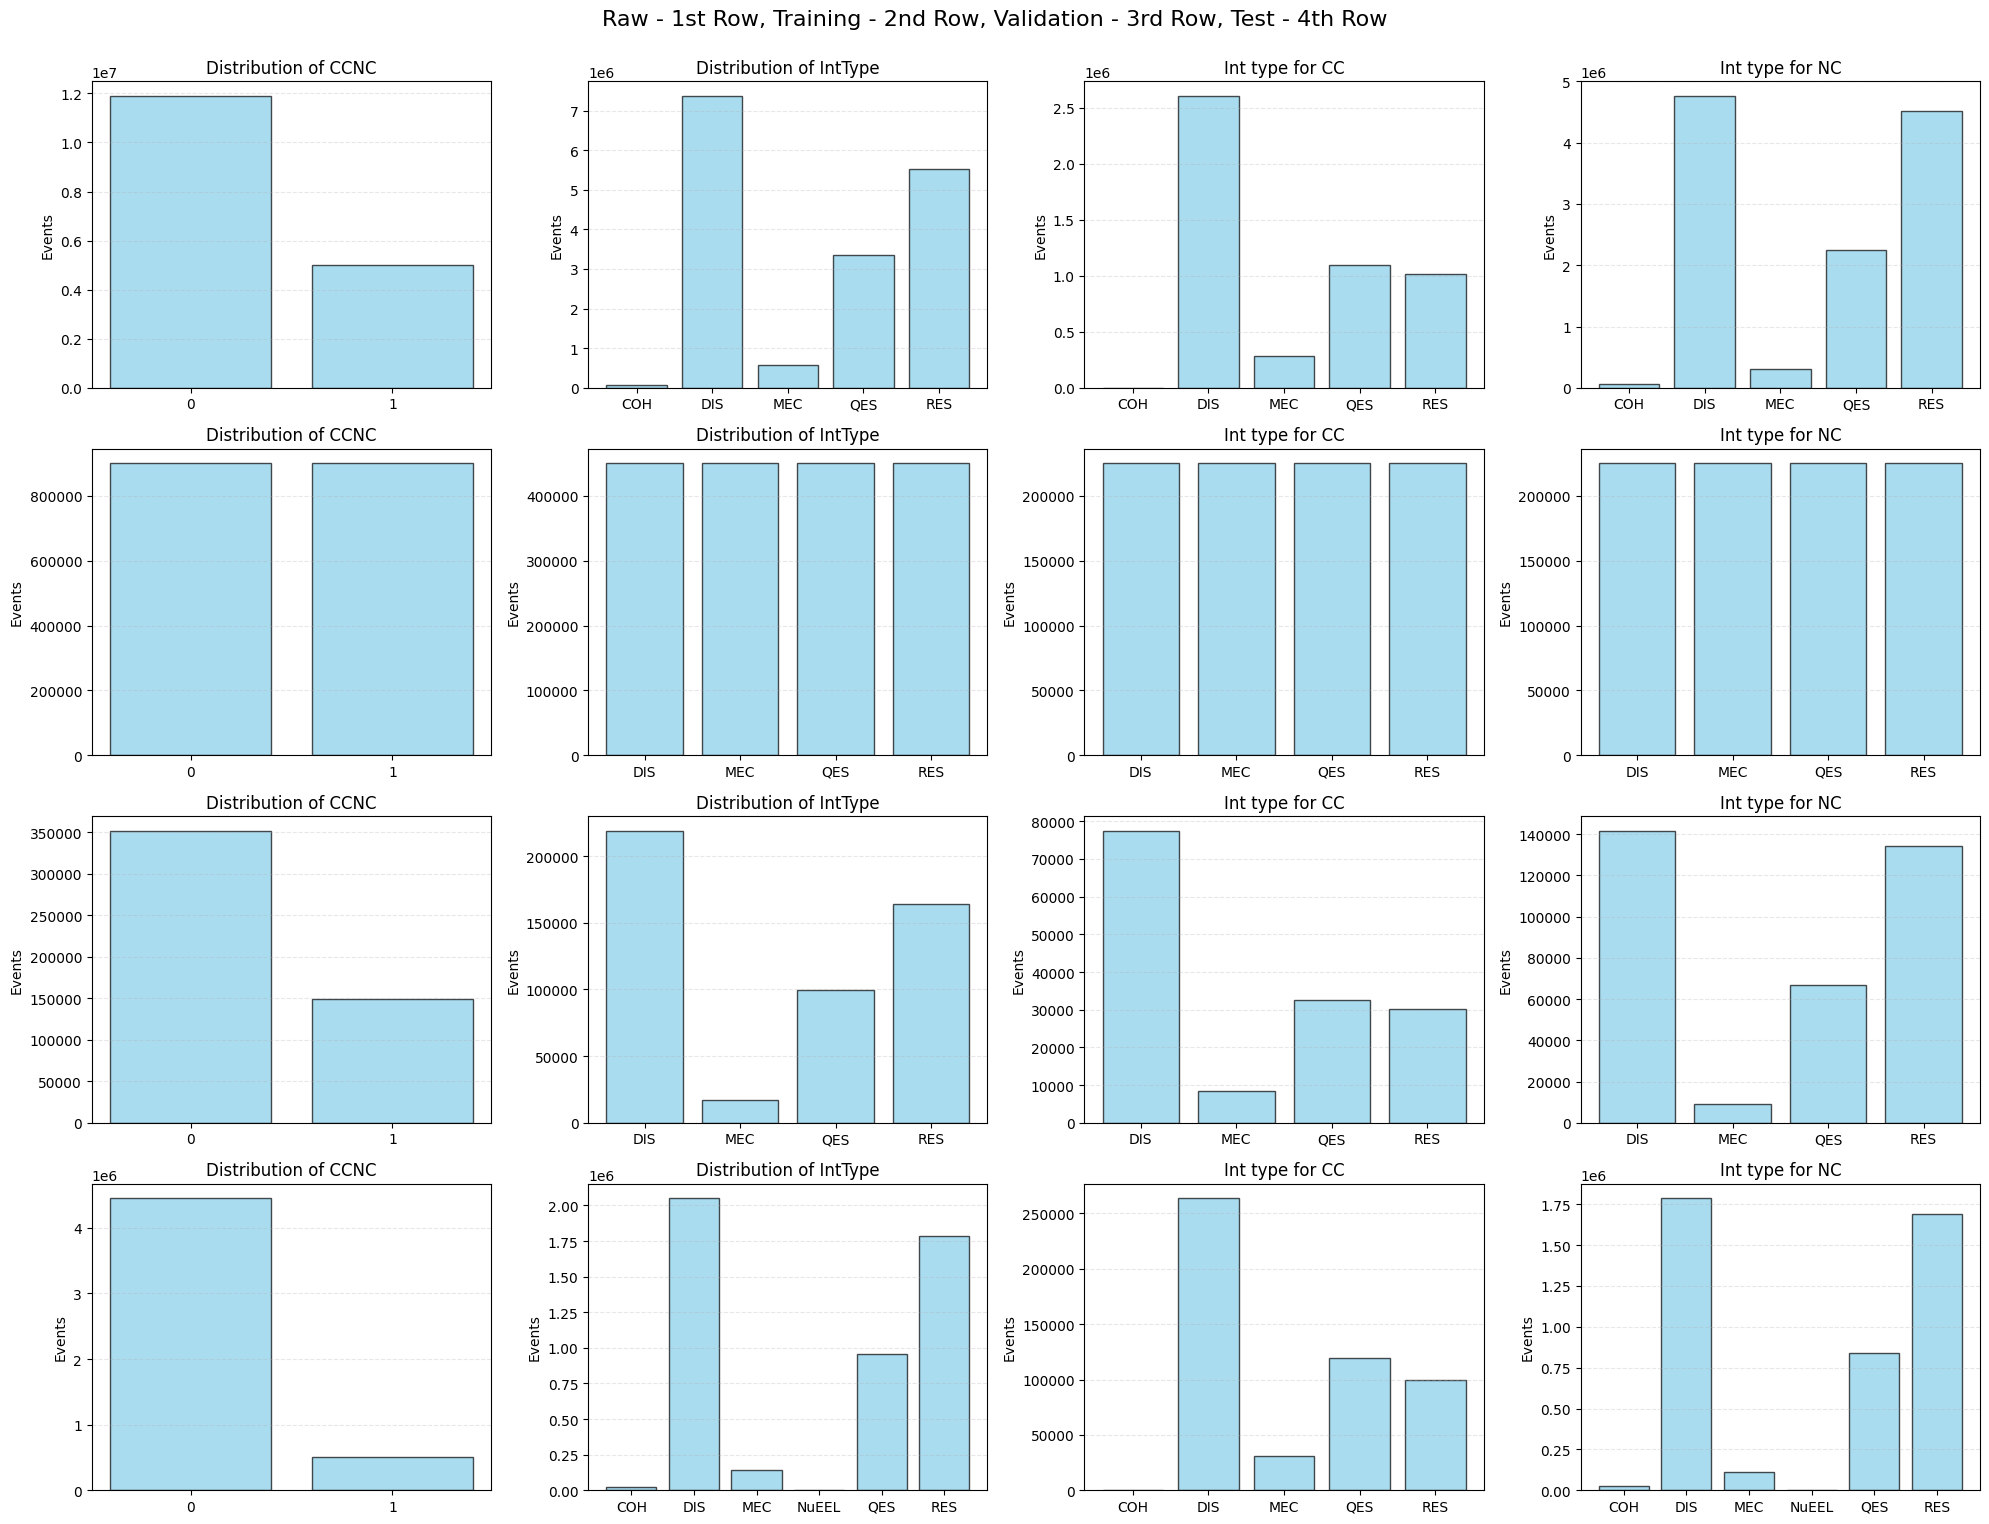

In [12]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

plt.suptitle("Raw - 1st Row, Training - 2nd Row, Validation - 3rd Row, Test - 4th Row", fontsize=16)

pf.plot_physics_results(df_legacy, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=False)
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[0,1], density=False)
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter=1, int_filter=None, ax=axes[0,2], density=False)
axes[0,2].set_title("Int type for CC")
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter=0, int_filter=None, ax=axes[0,3], density=False)
axes[0,3].set_title("Int type for NC")

pf.plot_physics_results(df_balanced_train, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[1,0], density=False)
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[1,1], density=False)
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter=1, int_filter=None, ax=axes[1,2], density=False)
axes[1,2].set_title("Int type for CC")
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter=0, int_filter=None, ax=axes[1,3], density=False)
axes[1,3].set_title("Int type for NC")

pf.plot_physics_results(df_unbalanced_val, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=False)
pf.plot_physics_results(df_unbalanced_val, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[2,1], density=False)
pf.plot_physics_results(df_unbalanced_val, column='IntType', ccnc_filter=1, int_filter=None, ax=axes[2,2], density=False)
axes[2,2].set_title("Int type for CC")
pf.plot_physics_results(df_unbalanced_val, column='IntType', ccnc_filter=0, int_filter=None, ax=axes[2,3], density=False)
axes[2,3].set_title("Int type for NC")

pf.plot_physics_results(df_unbalanced_test, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[3,0], density=False)
pf.plot_physics_results(df_unbalanced_test, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[3,1], density=False)
pf.plot_physics_results(df_unbalanced_test, column='IntType', ccnc_filter=1, int_filter=None, ax=axes[3,2], density=False)
axes[3,2].set_title("Int type for CC")
pf.plot_physics_results(df_unbalanced_test, column='IntType', ccnc_filter=0, int_filter=None, ax=axes[3,3], density=False)
axes[3,3].set_title("Int type for NC")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


# Plotting Class Separation Hypothesis for the Training Set
Histrogramy dla próbek wygenerowanych osobno dla CC (3.5-30 GeV, 5 mln) oraz NC (0.5-30 GeV, 12 mln).
Redukcja przypadków do ~1.8 mln eventów z równolicznymi klasami

Sprawdzenie zbieżności zbiorów

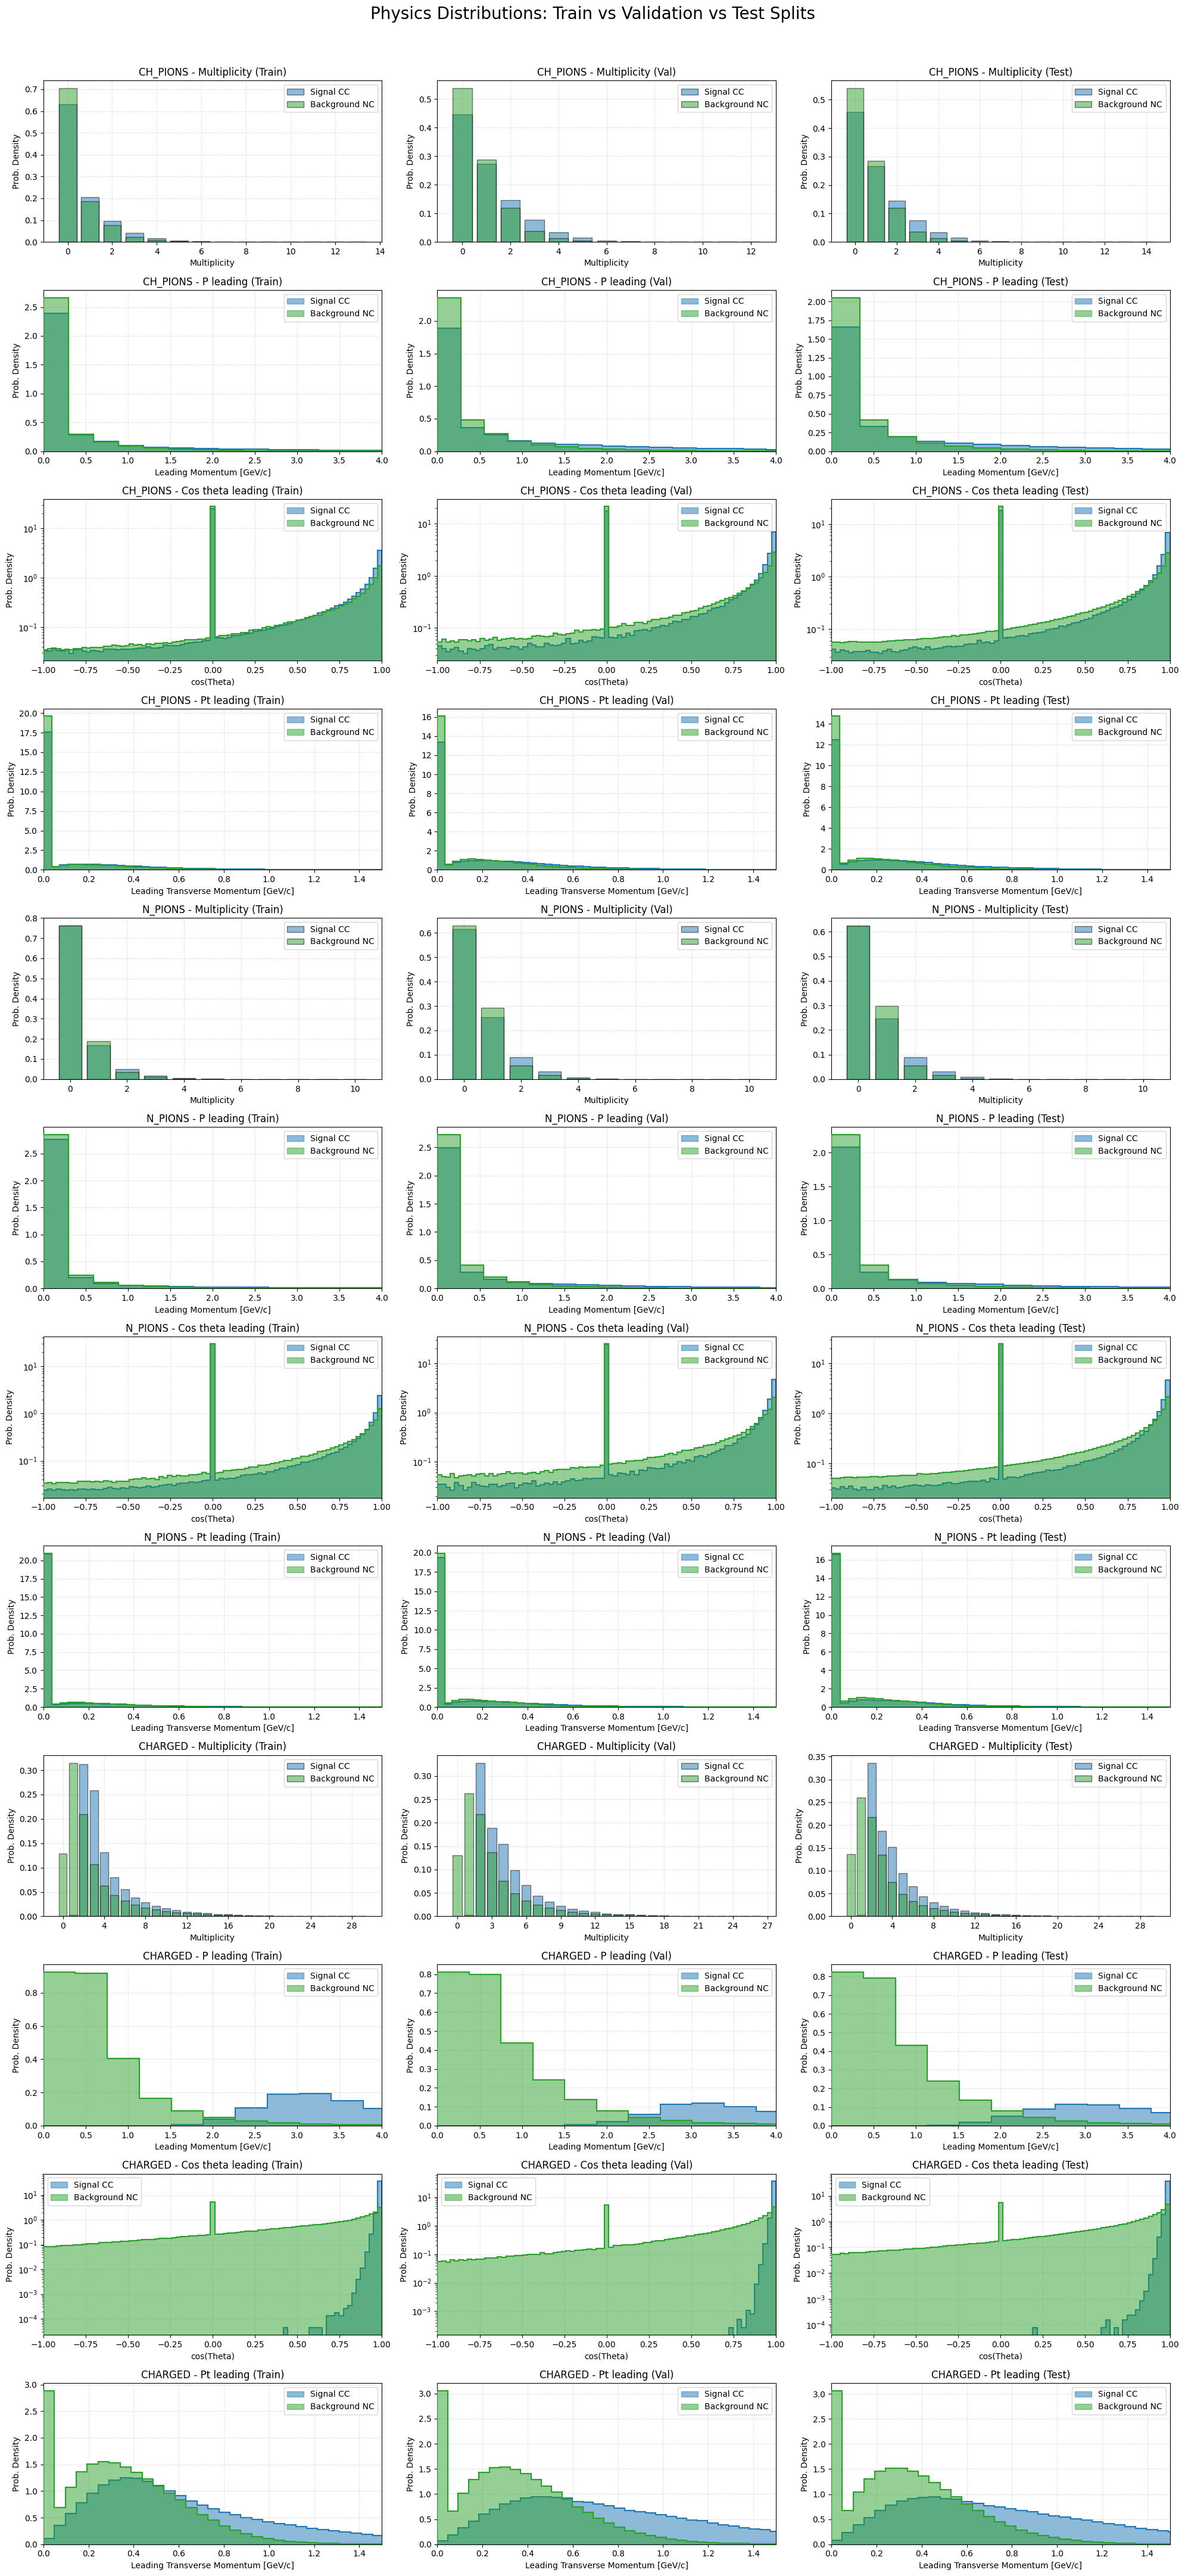

In [13]:
if full_plot:

    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)
    # 1. Prepare your CC / NC splits for all three datasets
    df_train_CC = df_balanced_train[df_balanced_train['CCNC'] == 1]
    df_train_NC = df_balanced_train[df_balanced_train['CCNC'] == 0]

    df_val_CC = df_unbalanced_val[df_unbalanced_val['CCNC'] == 1]
    df_val_NC = df_unbalanced_val[df_unbalanced_val['CCNC'] == 0]

    df_test_CC = df_unbalanced_test[df_unbalanced_test['CCNC'] == 1]
    df_test_NC = df_unbalanced_test[df_unbalanced_test['CCNC'] == 0]

    # 2. Define structural iterations
    modes = ['ch_pions', 'n_pions', 'charged']
    features = ['multiplicity', 'p_leading', 'cos_theta_leading', 'pt_leading']
    
    # Columns map to these datasets
    columns_data = [
        {"dfs": [df_train_CC, df_train_NC], "split_name": "Train"},
        {"dfs": [df_val_CC, df_val_NC],     "split_name": "Val"},
        {"dfs": [df_test_CC, df_test_NC],   "split_name": "Test"}
    ]

    # Feature-specific plot tweaks (x-limits and log scales to preserve visibility)
    feature_configs = {
        'multiplicity':      {'xlim': None, 'log': False},
        'p_leading':         {'xlim': (0, 4), 'log': False},
        'pt_leading':        {'xlim': (0, 1.5), 'log': False},
        'cos_theta_leading': {'xlim': (-1, 1), 'log': True} # Log scale handles the severe spike at 1.0 or 0.0
    }

    # 3. Initialize the 12x3 canvas
    fig, axes = plt.subplots(12, 3, figsize=(20, 45)) 
    
    row_idx = 0
    for mode in modes:
        for feature in features:
            config = feature_configs[feature]
            
            for col_idx, col in enumerate(columns_data):
                ax = axes[row_idx, col_idx]
                
                # Plot CC vs NC line for this specific block
                pf.plot_physics_single_canva(
                    dfs=col["dfs"], 
                    mode=mode, 
                    feature=feature, 
                    titles=["Signal CC", "Background NC"], 
                    ax=ax, 
                    density=True, # Keep Count on y-axis as requested
                    full_color_list=['#1f77b4', '#2ca02c'] # Distinct Blue for CC, Green for NC
                )
                
                # Apply custom configurations
                if config['xlim']:
                    ax.set_xlim(config['xlim'])
                if config['log']:
                    ax.set_yscale('log')
                    
                # Append the dataset split name to the title
                ax.set_title(f"{ax.get_title()} ({col['split_name']})")
                
            row_idx += 1

    plt.suptitle("Physics Distributions: Train vs Validation vs Test Splits", fontsize=20, y=0.99)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    # rect=[left, bottom, right, top] in normalized 0-1 coordinates
    plt.show()

## Transforming data to tensors 

In [ ]:
import analysis.scripts.preprocess_functions as prf
importlib.reload(prf)



if scaling_factor < 0.1:
    batch_size=32
elif scaling_factor > 0.1 and scaling_factor < 0.5:
    batch_size=64
elif scaling_factor > 0.5 and scaling_factor < 0.9:
    batch_size=128  
else: batch_size=1024

train_data = prf.tensorize_data(df_balanced_train, batch_size=batch_size)
val_data = prf.tensorize_data(df_unbalanced_val, batch_size=batch_size)
test_data = prf.tensorize_data(df_unbalanced_test, batch_size=batch_size)

#speed measurement
tfds.benchmark(train_data)
tfds.benchmark(val_data)
tfds.benchmark(test_data)



************ Summary ************



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1758/1758 [00:01<00:00, 881.20it/s]


Examples/sec (First included) 859.46 ex/sec (total: 1759 ex, 2.05 sec)
Examples/sec (First only) 18.07 ex/sec (total: 1 ex, 0.06 sec)
Examples/sec (First excluded) 882.84 ex/sec (total: 1758 ex, 1.99 sec)

************ Summary ************



 74%|████████████████████████████████████████████████████████████████████████████▌                           | 360/489 [00:00<00:00, 887.34it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 489/489 [00:00<00:00, 880.57it/s]


Examples/sec (First included) 866.55 ex/sec (total: 490 ex, 0.57 sec)
Examples/sec (First only) 77.40 ex/sec (total: 1 ex, 0.01 sec)
Examples/sec (First excluded) 885.00 ex/sec (total: 489 ex, 0.55 sec)

************ Summary ************



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 4846/4846 [00:05<00:00, 886.35it/s]

Examples/sec (First included) 860.52 ex/sec (total: 4847 ex, 5.63 sec)
Examples/sec (First only) 5.96 ex/sec (total: 1 ex, 0.17 sec)
Examples/sec (First excluded) 886.75 ex/sec (total: 4846 ex, 5.46 sec)


,duration,num_examples,avg
first+lasts,5.632649,4847,860.518699
first,0.167741,1,5.961569
lasts,5.464908,4846,886.748661


2026-05-25 13:06:07.459927: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:134] retrieving CUDA diagnostic information for host: heplb76
2026-05-25 13:06:07.459948: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:141] hostname: heplb76
2026-05-25 13:06:07.460008: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:165] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2026-05-25 13:06:07.460038: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:169] kernel reported version is: 470.256.2
2026-05-25 13:06:10.153021: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:10.723586: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:16.360679: W tensorflow/core/framework/local_rendezvous.cc:404] Local

## Verifying tensors-pandas coherence for the training set

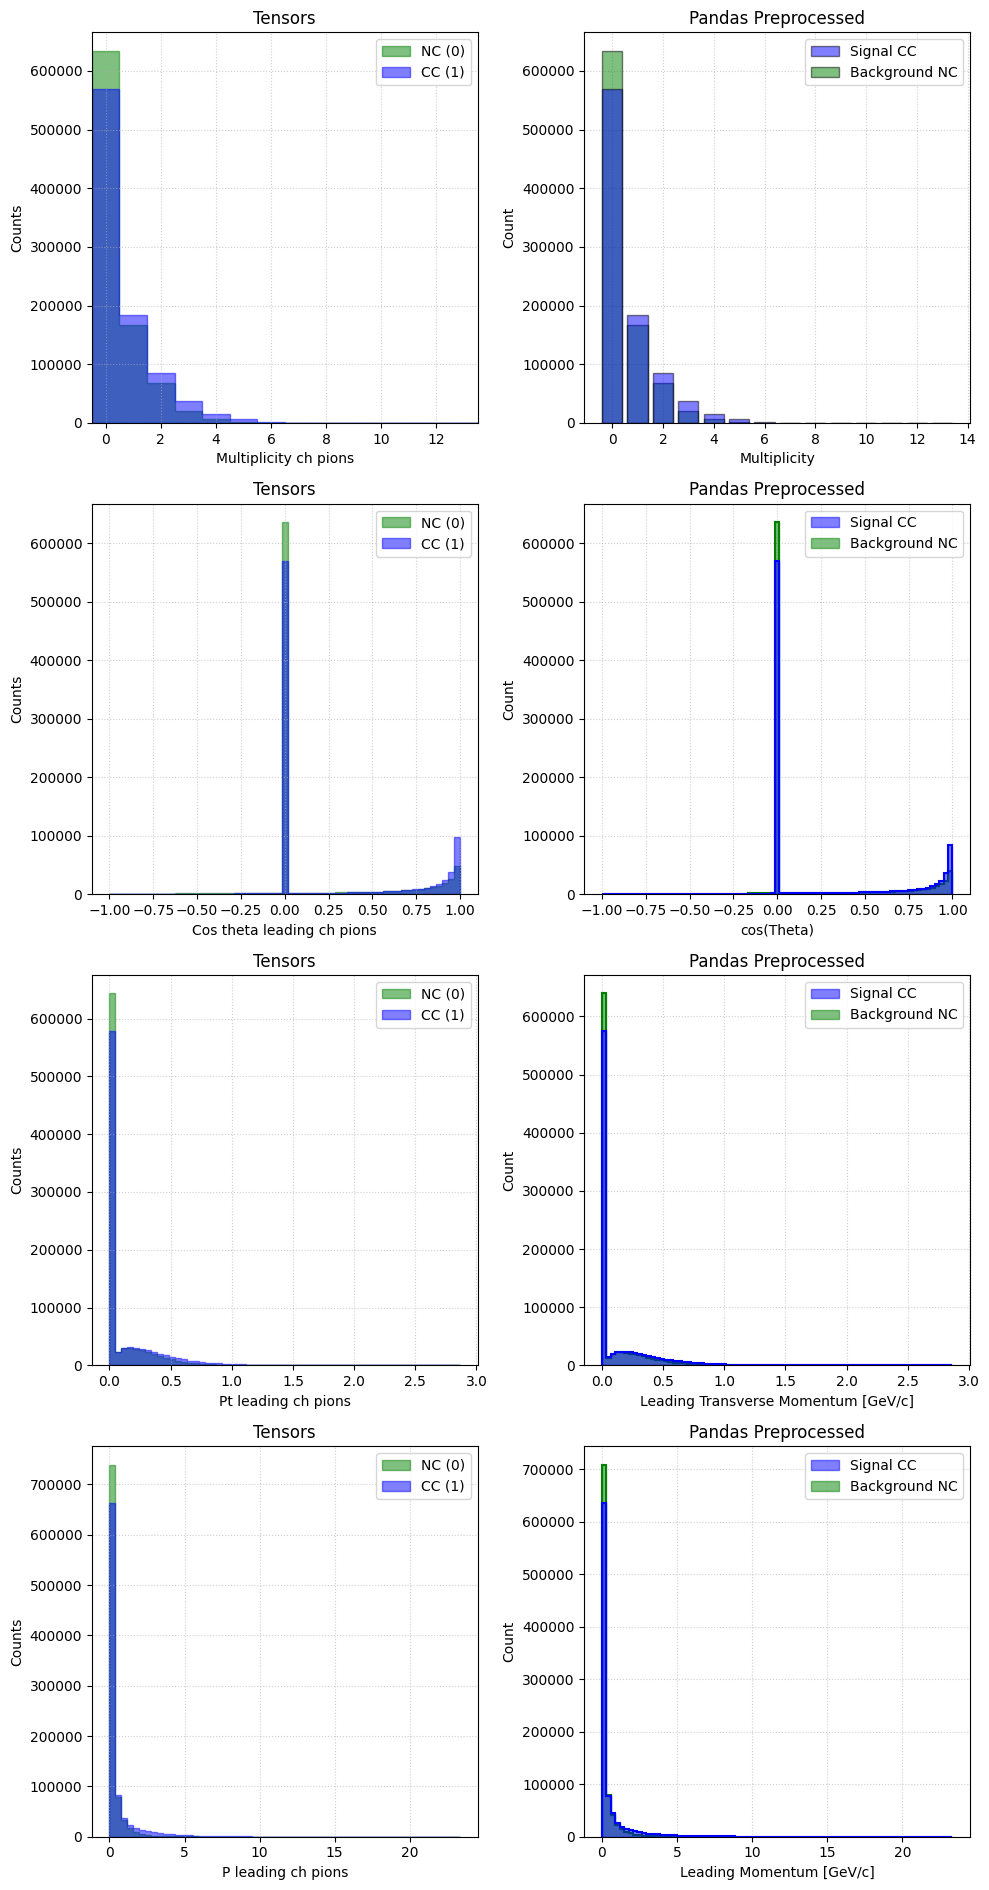

2026-05-25 13:06:18.802015: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:21.069054: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:23.426699: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:25.794561: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
if full_plot:
    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

        # 0:  'p_leading_ch_pions',
        # 1:  'pt_leading_ch_pions',
        # 2:  'cos_theta_leading_ch_pions',
        # 3:  'multiplicity_ch_pions',

    df_CC = df_balanced_train[df_balanced_train['CCNC'] == 1]
    df_NC = df_balanced_train[df_balanced_train['CCNC'] == 0]

    dfs_preprocessed = [None, df_CC, df_NC] 

    fig, axes = plt.subplots(4, 2, figsize=(10, 20))
    

    pf.plot_feature_from_dataset(train_data, 3, ax=axes[0, 0]) 
    axes[0,0].set_title("Tensors")     
    pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 1], density=False)
    axes[0,1].set_title("Pandas Preprocessed")  

    pf.plot_feature_from_dataset(train_data, 2, ax=axes[1, 0]) 
    axes[1,0].set_title("Tensors")    
    pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='cos_theta_leading', ax=axes[1, 1], density=False)
    axes[1,1].set_title("Pandas Preprocessed")    


    pf.plot_feature_from_dataset(train_data, 1, ax=axes[2, 0]) 
    axes[2,0].set_title("Tensors")    
    pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='pt_leading', ax=axes[2, 1], density=False)
    axes[2,1].set_title("Pandas Preprocessed")  

    pf.plot_feature_from_dataset(train_data, 0, ax=axes[3, 0]) # Neutral Leading p
    axes[3,0].set_title("Tensors")   
    pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[3, 1], density=False)
    axes[3,1].set_title("Pandas Preprocessed")  

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    # rect=[left, bottom, right, top] in normalized 0-1 coordinates
    plt.show()


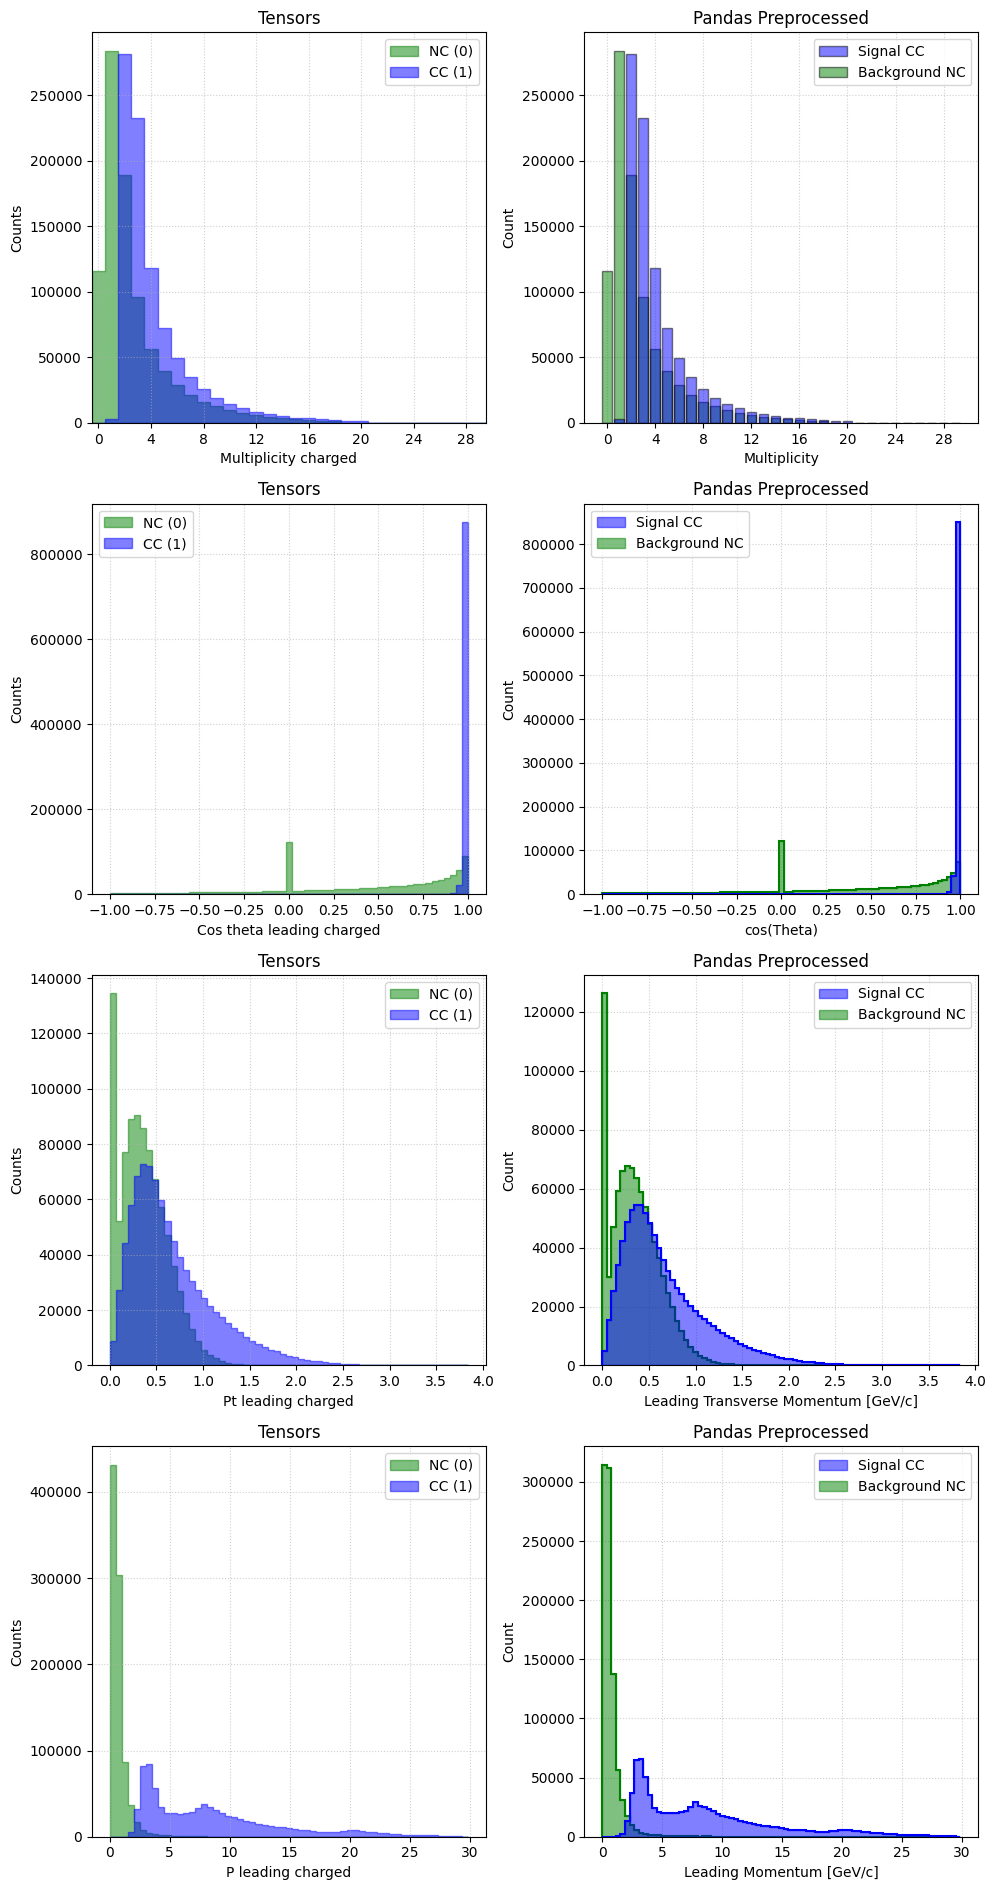

2026-05-25 13:06:29.645952: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:31.912621: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:34.463067: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:36.945602: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
if full_plot:
    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

        # 4:  'multiplicity_charged',
        # 5:  'p_leading_charged',
        # 6:  'pt_leading_charged',
        # 7:  'cos_theta_leading_charged',

    fig, axes = plt.subplots(4, 2, figsize=(10, 20))

    pf.plot_feature_from_dataset(train_data, 4, ax=axes[0, 0]) 
    axes[0,0].set_title("Tensors")     
    pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='multiplicity', ax=axes[0, 1], density=False)
    axes[0,1].set_title("Pandas Preprocessed")  

    pf.plot_feature_from_dataset(train_data, 7, ax=axes[1, 0]) 
    axes[1,0].set_title("Tensors")    
    pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='cos_theta_leading', ax=axes[1, 1], density=False)
    axes[1,1].set_title("Pandas Preprocessed")    


    pf.plot_feature_from_dataset(train_data, 6, ax=axes[2, 0]) 
    axes[2,0].set_title("Tensors")    
    pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='pt_leading', ax=axes[2, 1], density=False)
    axes[2,1].set_title("Pandas Preprocessed")  

    pf.plot_feature_from_dataset(train_data, 5, ax=axes[3, 0]) # Neutral Leading p
    axes[3,0].set_title("Tensors")   
    pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='p_leading', ax=axes[3, 1], density=False)
    axes[3,1].set_title("Pandas Preprocessed")  

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    # rect=[left, bottom, right, top] in normalized 0-1 coordinates
    plt.show()


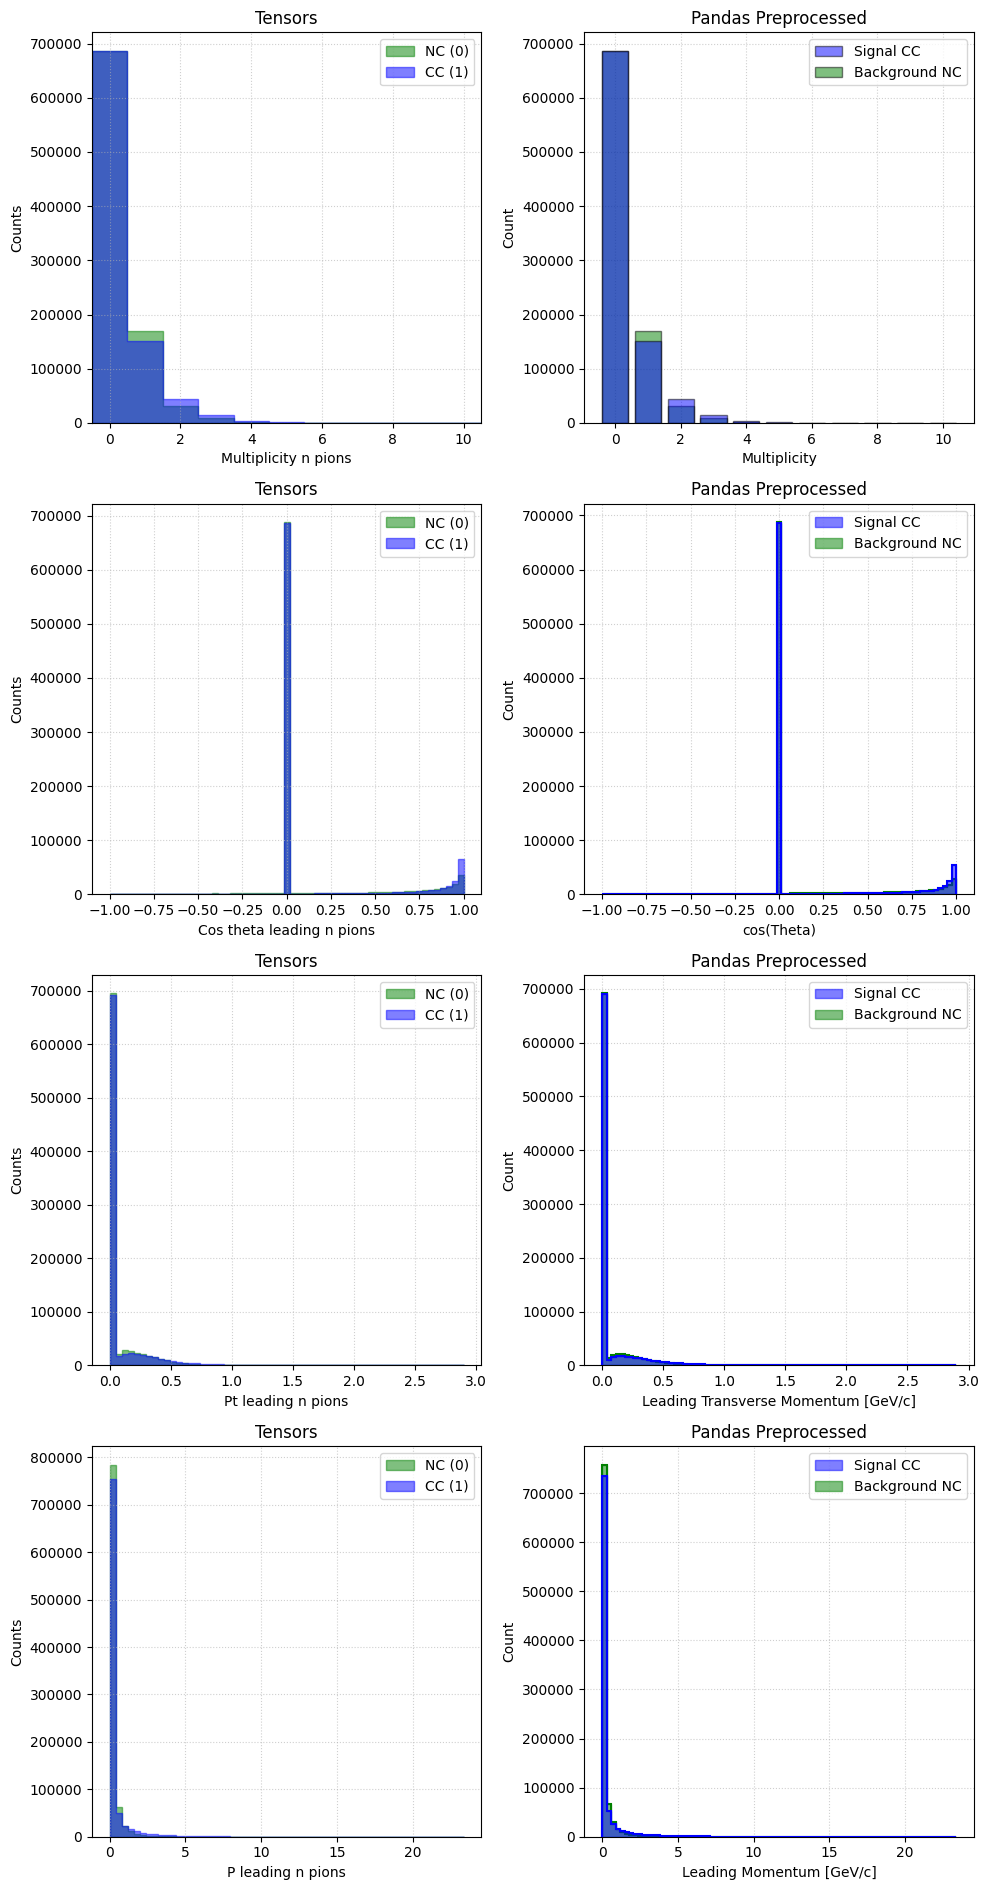

2026-05-25 13:06:40.980713: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:43.218324: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:45.553229: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 13:06:47.896425: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
if full_plot:
    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

        # 8:  'multiplicity_n_pions',
        # 9:  'p_leading_n_pions',
        # 10: 'pt_leading_n_pions',
        # 11: 'cos_theta_leading_n_pions'

    fig, axes = plt.subplots(4, 2, figsize=(10, 20))

    pf.plot_feature_from_dataset(train_data, 8, ax=axes[0, 0]) 
    axes[0,0].set_title("Tensors")     
    pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[0, 1], density=False)
    axes[0,1].set_title("Pandas Preprocessed")  

    pf.plot_feature_from_dataset(train_data, 11, ax=axes[1, 0]) 
    axes[1,0].set_title("Tensors")    
    pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='cos_theta_leading', ax=axes[1, 1], density=False)
    axes[1,1].set_title("Pandas Preprocessed")    


    pf.plot_feature_from_dataset(train_data, 10, ax=axes[2, 0]) 
    axes[2,0].set_title("Tensors")    
    pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='pt_leading', ax=axes[2, 1], density=False)
    axes[2,1].set_title("Pandas Preprocessed")  

    pf.plot_feature_from_dataset(train_data, 9, ax=axes[3, 0]) # Neutral Leading p
    axes[3,0].set_title("Tensors")   
    pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[3, 1], density=False)
    axes[3,1].set_title("Pandas Preprocessed")  

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    # rect=[left, bottom, right, top] in normalized 0-1 coordinates
    plt.show()


## Model

In [ ]:
#1dCNN

def getModel():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(12,1)), #12 features, 1 label, CNN specific input
        tf.keras.layers.BatchNormalization(),

        #brain - filters of 32 suffice, there was no improvement with 64
        tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        
        #pooling
        tf.keras.layers.Flatten(),
        # tf.keras.layers.GlobalAveragePooling1D(), #this yielded worse results than flatten

        #classification, 32 neurons didn't improve the model
        tf.keras.layers.Dense(16, activation='relu'),
        # tf.keras.layers.Dropout(0.1), #yielded worse results with 32-32-16 neuron structure
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name='1dCNN')
    return model


In [ ]:
if train:
    model_1dCNN = getModel()
    model_1dCNN.summary()   

Model: "1dCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 12, 1)          │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 12, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        12,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,933 (97.39 KB)

 Trainable params: 24,931 (97.39 KB)

 Non-trainable params: 2 (8.00 B)

## Training

In [ ]:
if train:
    import analysis.scripts.system_functions as sf
    importlib.reload(sf)

    metrics = [
        # TP rate 
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        # FP rate 
        tf.keras.metrics.Precision(name='precision')

    

    ]

    initial_learning_rate = 5E-4 #5E-5 was good
    #####
    nEpochs = 150
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps= nEpochs * (training_size // batch_size), # Total steps
    alpha=0.02 # Minimum learning rate floor (5E-4 * 0.02 = 1E-5)
    )

    #batch_size defined when creating the datasets
    early_stop_callback = tf.keras.callbacks.EarlyStopping(monitor='val_pr_auc', #what to monitor
                                                mode='max', #we want to minimize the loss
                                                patience=5,     #epochs
                                                min_delta=1E-5,  #change
                                                restore_best_weights=True,
                                                verbose=1)

    if not save:
        callbacks = [] #for testing disable checkpoints

    if save:
        current_run_dir = sf.get_experiment_folder("1DCNN_training")
        checkpoint_filepath = os.path.join(current_run_dir, 'checkpoint_epoch_{epoch:02d}.weights.h5')
        model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, save_weights_only=True, monitor='val_pr_auc', mode='max', save_best_only=True, verbose=1)
        final_model_path = os.path.join(current_run_dir, "final_model_full.keras")


    if save:
        callbacks = [model_checkpoint_callback, early_stop_callback]


    model_1dCNN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                loss='binary_crossentropy', metrics=metrics)

--- Experiment directory created: checkpoints/2026-05-25_1DCNN_training(6) ---


In [21]:
if train:
    history = model_1dCNN.fit(
        train_data,
        validation_data=val_data,
        epochs=nEpochs,
        callbacks=callbacks,
        verbose=1
    )

Epoch 1/150
1754/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9733 - auc: 0.9936 - loss: 0.0992 - pr_auc: 0.9931 - precision: 0.9650 - recall: 0.9835
Epoch 1: val_pr_auc improved from -inf to 0.99204, saving model to checkpoints/2026-05-25_1DCNN_training(6)/checkpoint_epoch_01.weights.h5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9734 - auc: 0.9936 - loss: 0.0990 - pr_auc: 0.9931 - precision: 0.9651 - recall: 0.9836 - val_accuracy: 0.9806 - val_auc: 0.9976 - val_loss: 0.0552 - val_pr_auc: 0.9920 - val_precision: 0.9458 - val_recall: 0.9915
Epoch 2/150
1756/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9892 - auc: 0.9987 - loss: 0.0323 - pr_auc: 0.9981 - precision: 0.9857 - recall: 0.9928
Epoch 2: val_pr_auc improved from 0.99204 to 0.99234, saving model to checkpoints/2026-05-25_1DCNN_training(6)/checkpoint_epoch_02.weights.h5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9892 - auc: 0.9987 - loss: 0.0323 - pr_auc: 0.9981 - precision: 0.9857 

1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9896 - auc: 0.9988 - loss: 0.0308 - pr_auc: 0.9982 - precision: 0.9861 - recall: 0.9933
Epoch 4: val_pr_auc improved from 0.99268 to 0.99292, saving model to checkpoints/2026-05-25_1DCNN_training(6)/checkpoint_epoch_04.weights.h5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9896 - auc: 0.9988 - loss: 0.0308 - pr_auc: 0.9982 - precision: 0.9861 - recall: 0.9933 - val_accuracy: 0.9819 - val_auc: 0.9979 - val_loss: 0.0506 - val_pr_auc: 0.9929 - val_precision: 0.9511 - val_recall: 0.9900
Epoch 5/150
1756/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9897 - auc: 0.9988 - loss: 0.0305 - pr_auc: 0.9982 - precision: 0.9862 - recall: 0.9933
Epoch 5: val_pr_auc improved from 0.99292 to 0.99302, saving model to checkpoints/2026-05-25_1DCNN_training(6)/checkpoint_epoch_05.weights.h5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9897 - auc: 0.9988 - loss: 0.0305 - pr_auc: 0.9982 - precision: 0.9862 - recall:

## Comet Exp Tracking

In [22]:
if track:
  experiment = comet_ml.start(
    api_key="8fJ8LDvz6YAWkbOxeK3ibVvsA",
    project_name="1dcnn-dune",
    workspace="grzegorz-j-drzejowski"
  )


  hyper_params = {
    "learning_rate": initial_learning_rate,
    "steps": nEpochs,
    "batch_size": batch_size,
  }

  experiment.log_parameters(hyper_params)


In [23]:
if track:
    experiment.end()

## Save model

In [24]:
accept_model = 0
if accept_model:
    #optionally save the model explicitly (for good performing models to seperate them)
    os.makedirs("models", exist_ok=True)
    path = "models/1DCNN_.keras"
    model_1dCNN.save(path.format(epoch=nEpochs))

    print(f"Model saved successfully to {path.format(epoch=nEpochs)}")

## Load Model

In [25]:
load_model = 0
if load_model:
    #wczytanie modelu
    nEpochsSaved = nEpochs

    checkpoint_path = "models/1DCNN-full-set-AGP.keras"
    model_load_ = tf.keras.models.load_model(checkpoint_path.format(epoch=nEpochsSaved))

    # model_load_.evaluate(val_data)
    # model_1dCNN.evaluate(val_data)

In [26]:
load_checkpoint = 0
if load_checkpoint:

    run_folder = "checkpoints/2026-05-25_1DCNN_training/" # selecting folder
    epoch_to_load = 38

    model_load = getModel() 
    weights_path = os.path.join(run_folder, f"checkpoint_epoch_{epoch_to_load:02d}.weights.h5")

    # load the weights into the architecture
    if os.path.exists(weights_path):
        print(f"Loading weights from: {weights_path}")
        model_load.load_weights(weights_path)
        
        # 5. Compile is REQUIRED before evaluation to define the loss/metrics
        model_load.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3E-4),
            loss='binary_crossentropy', metrics=metrics)
        
        # 6. Evaluate
        eval_results = model_load.evaluate(val_data)

        print(f"\n--- Evaluation Results for Epoch {epoch_to_load} ---")
        # Index 0 is always the loss
        print(f"Validation Loss:      {eval_results[0]:.6f}") 
        print(f"Validation PR-AUC:    {eval_results[3]:.4f}")
        #     metrics = [
        # # TP rate 
        # tf.keras.metrics.Recall(name='recall'),
        # tf.keras.metrics.AUC(name='auc'),
        # tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        # tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        # # FP rate 
        # tf.keras.metrics.Precision(name='precision')

    else:
        print(f"Error: File not found at {weights_path}")

    model_1dCNN = model_load

## Evaluation

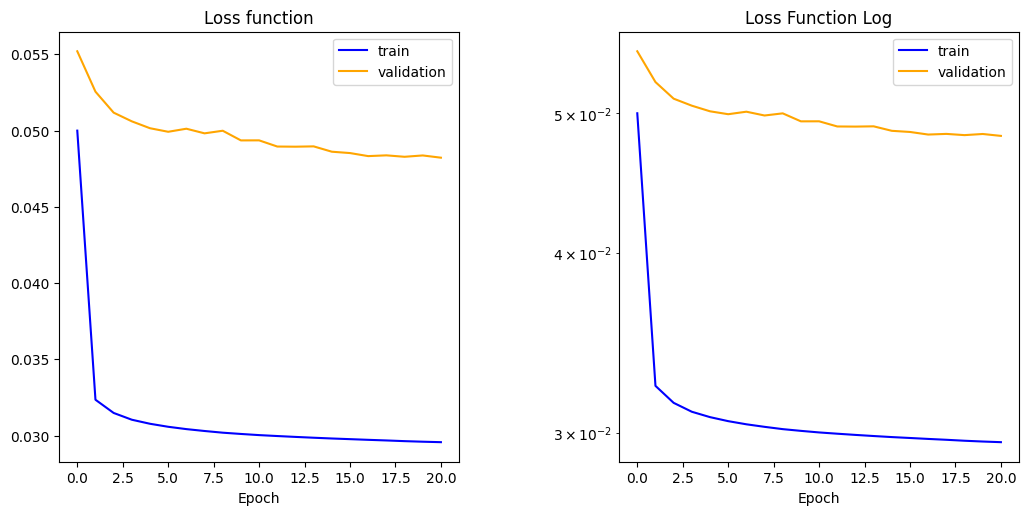

In [27]:
# eval training 
if train and (not load_checkpoint or load_model):
    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

    pf.plotTrainHistory(history)

In [28]:
#this would require modification in ensamble mode
# 1. Get predictions and flatten them to 1D
train_preds = model_1dCNN.predict(train_data).flatten()
val_preds = model_1dCNN.predict(val_data).flatten()
test_preds = model_1dCNN.predict(test_data).flatten()

df_balanced_train['Prob_is_CC'] = train_preds
df_unbalanced_val['Prob_is_CC'] = val_preds
df_unbalanced_test['Prob_is_CC'] = test_preds

# 3. Decision: 1 = Predicted CC, 0 = Predicted NC

decision_threshold = 0.5

df_balanced_train['NN_Decision_CC'] = (train_preds > decision_threshold).astype(int)
df_unbalanced_val['NN_Decision_CC'] = (val_preds > decision_threshold).astype(int)
df_unbalanced_test['NN_Decision_CC'] = (test_preds > decision_threshold).astype(int)


 368/1758 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step


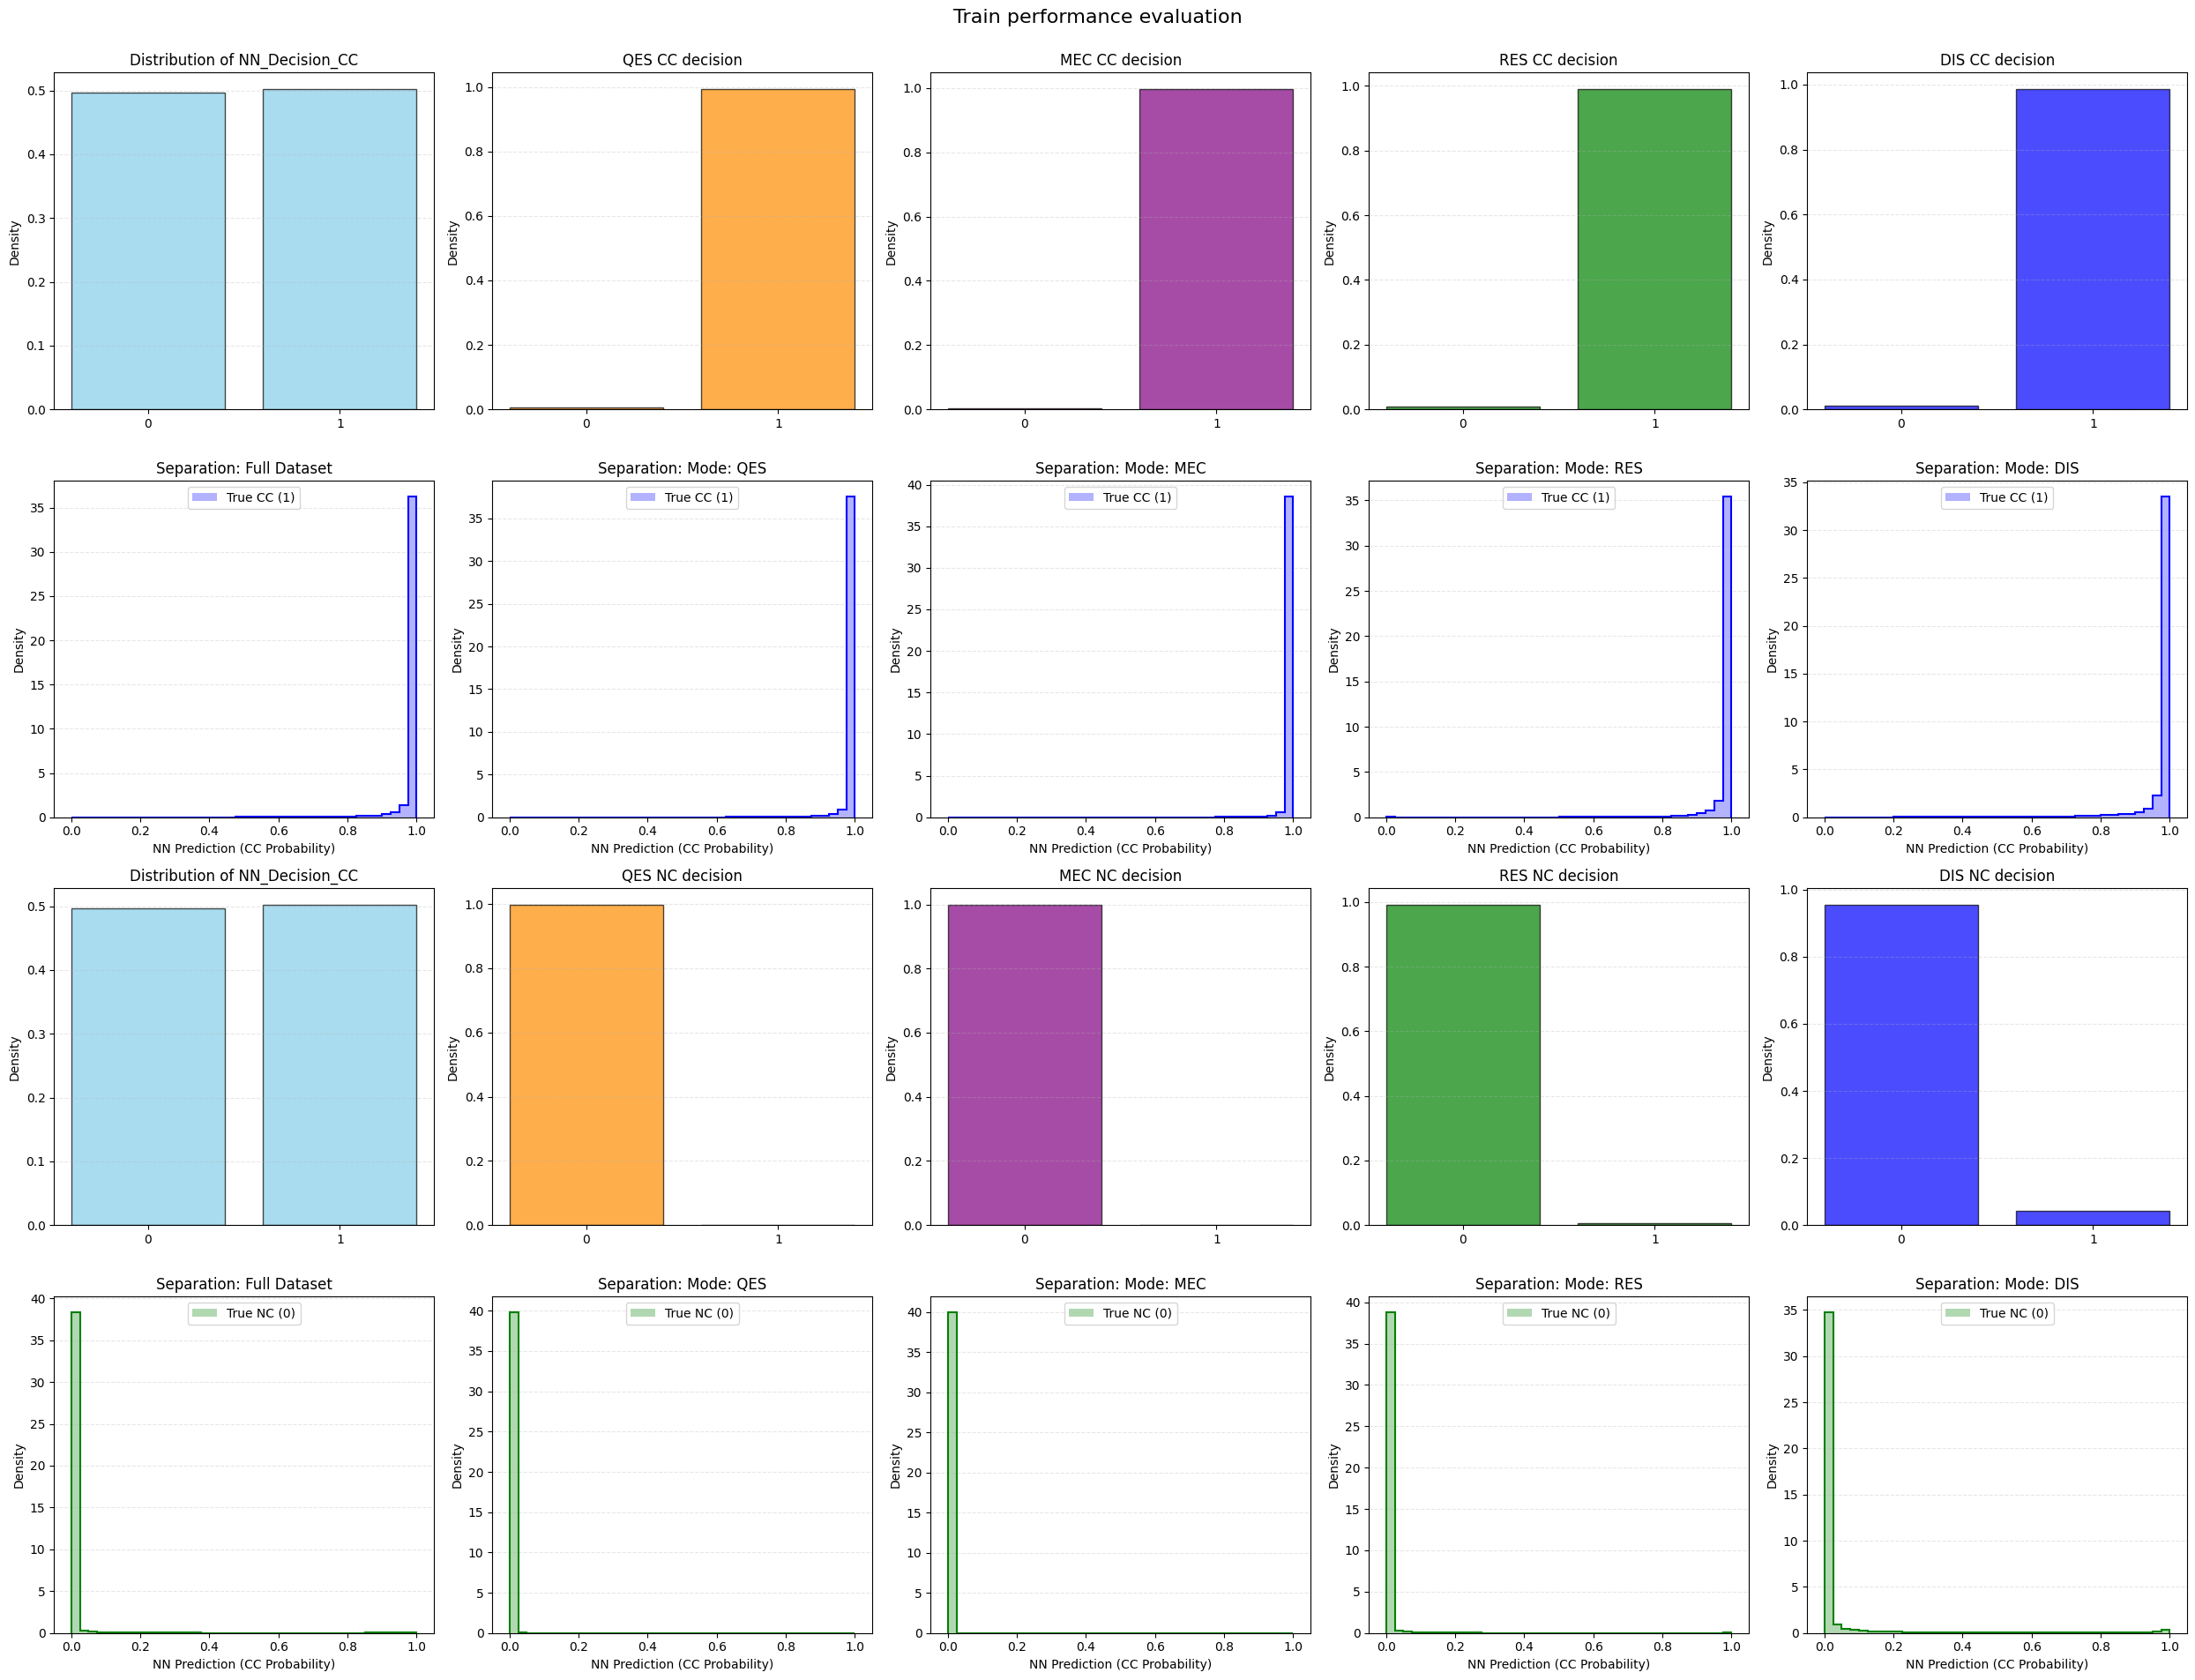

In [29]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

#training before after eval before after (4 cokumns), ccnn, int type (2 rows)
fig, axes = plt.subplots(4, 5, figsize=(25, 20))

plt.suptitle("Decision plots (1 is CC)", fontsize=16)

pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=1, int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
axes[0,1].set_title("QES CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=1, int_filter='MEC', ax=axes[0,2], density=True, color='purple')
axes[0,2].set_title("MEC CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=1, int_filter='RES', ax=axes[0,3], density=True, color='green')
axes[0,3].set_title("RES CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=1, int_filter='DIS', ax=axes[0,4], density=True, color='blue')
axes[0,4].set_title("DIS CC decision")


pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter=None, ax=axes[1,0], density=True, bins=None)
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter='MEC', ax=axes[1,2], density=True, color='purple')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter='RES', ax=axes[1,3], density=True, color='green')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter='DIS', ax=axes[1,4], density=True, color='blue')


pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=0, int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
axes[2,1].set_title("QES NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=0, int_filter='MEC', ax=axes[2,2], density=True, color='purple')
axes[2,2].set_title("MEC NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=0, int_filter='RES', ax=axes[2,3], density=True, color='green')
axes[2,3].set_title("RES NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=0, int_filter='DIS', ax=axes[2,4], density=True, color='blue')
axes[2,4].set_title("DIS NC decision")


pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter=None, ax=axes[3,0], density=True, bins=None)
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter='MEC', ax=axes[3,2], density=True, color='purple')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter='RES', ax=axes[3,3], density=True, color='green')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter='DIS', ax=axes[3,4], density=True, color='blue')

plt.suptitle("Train performance evaluation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()



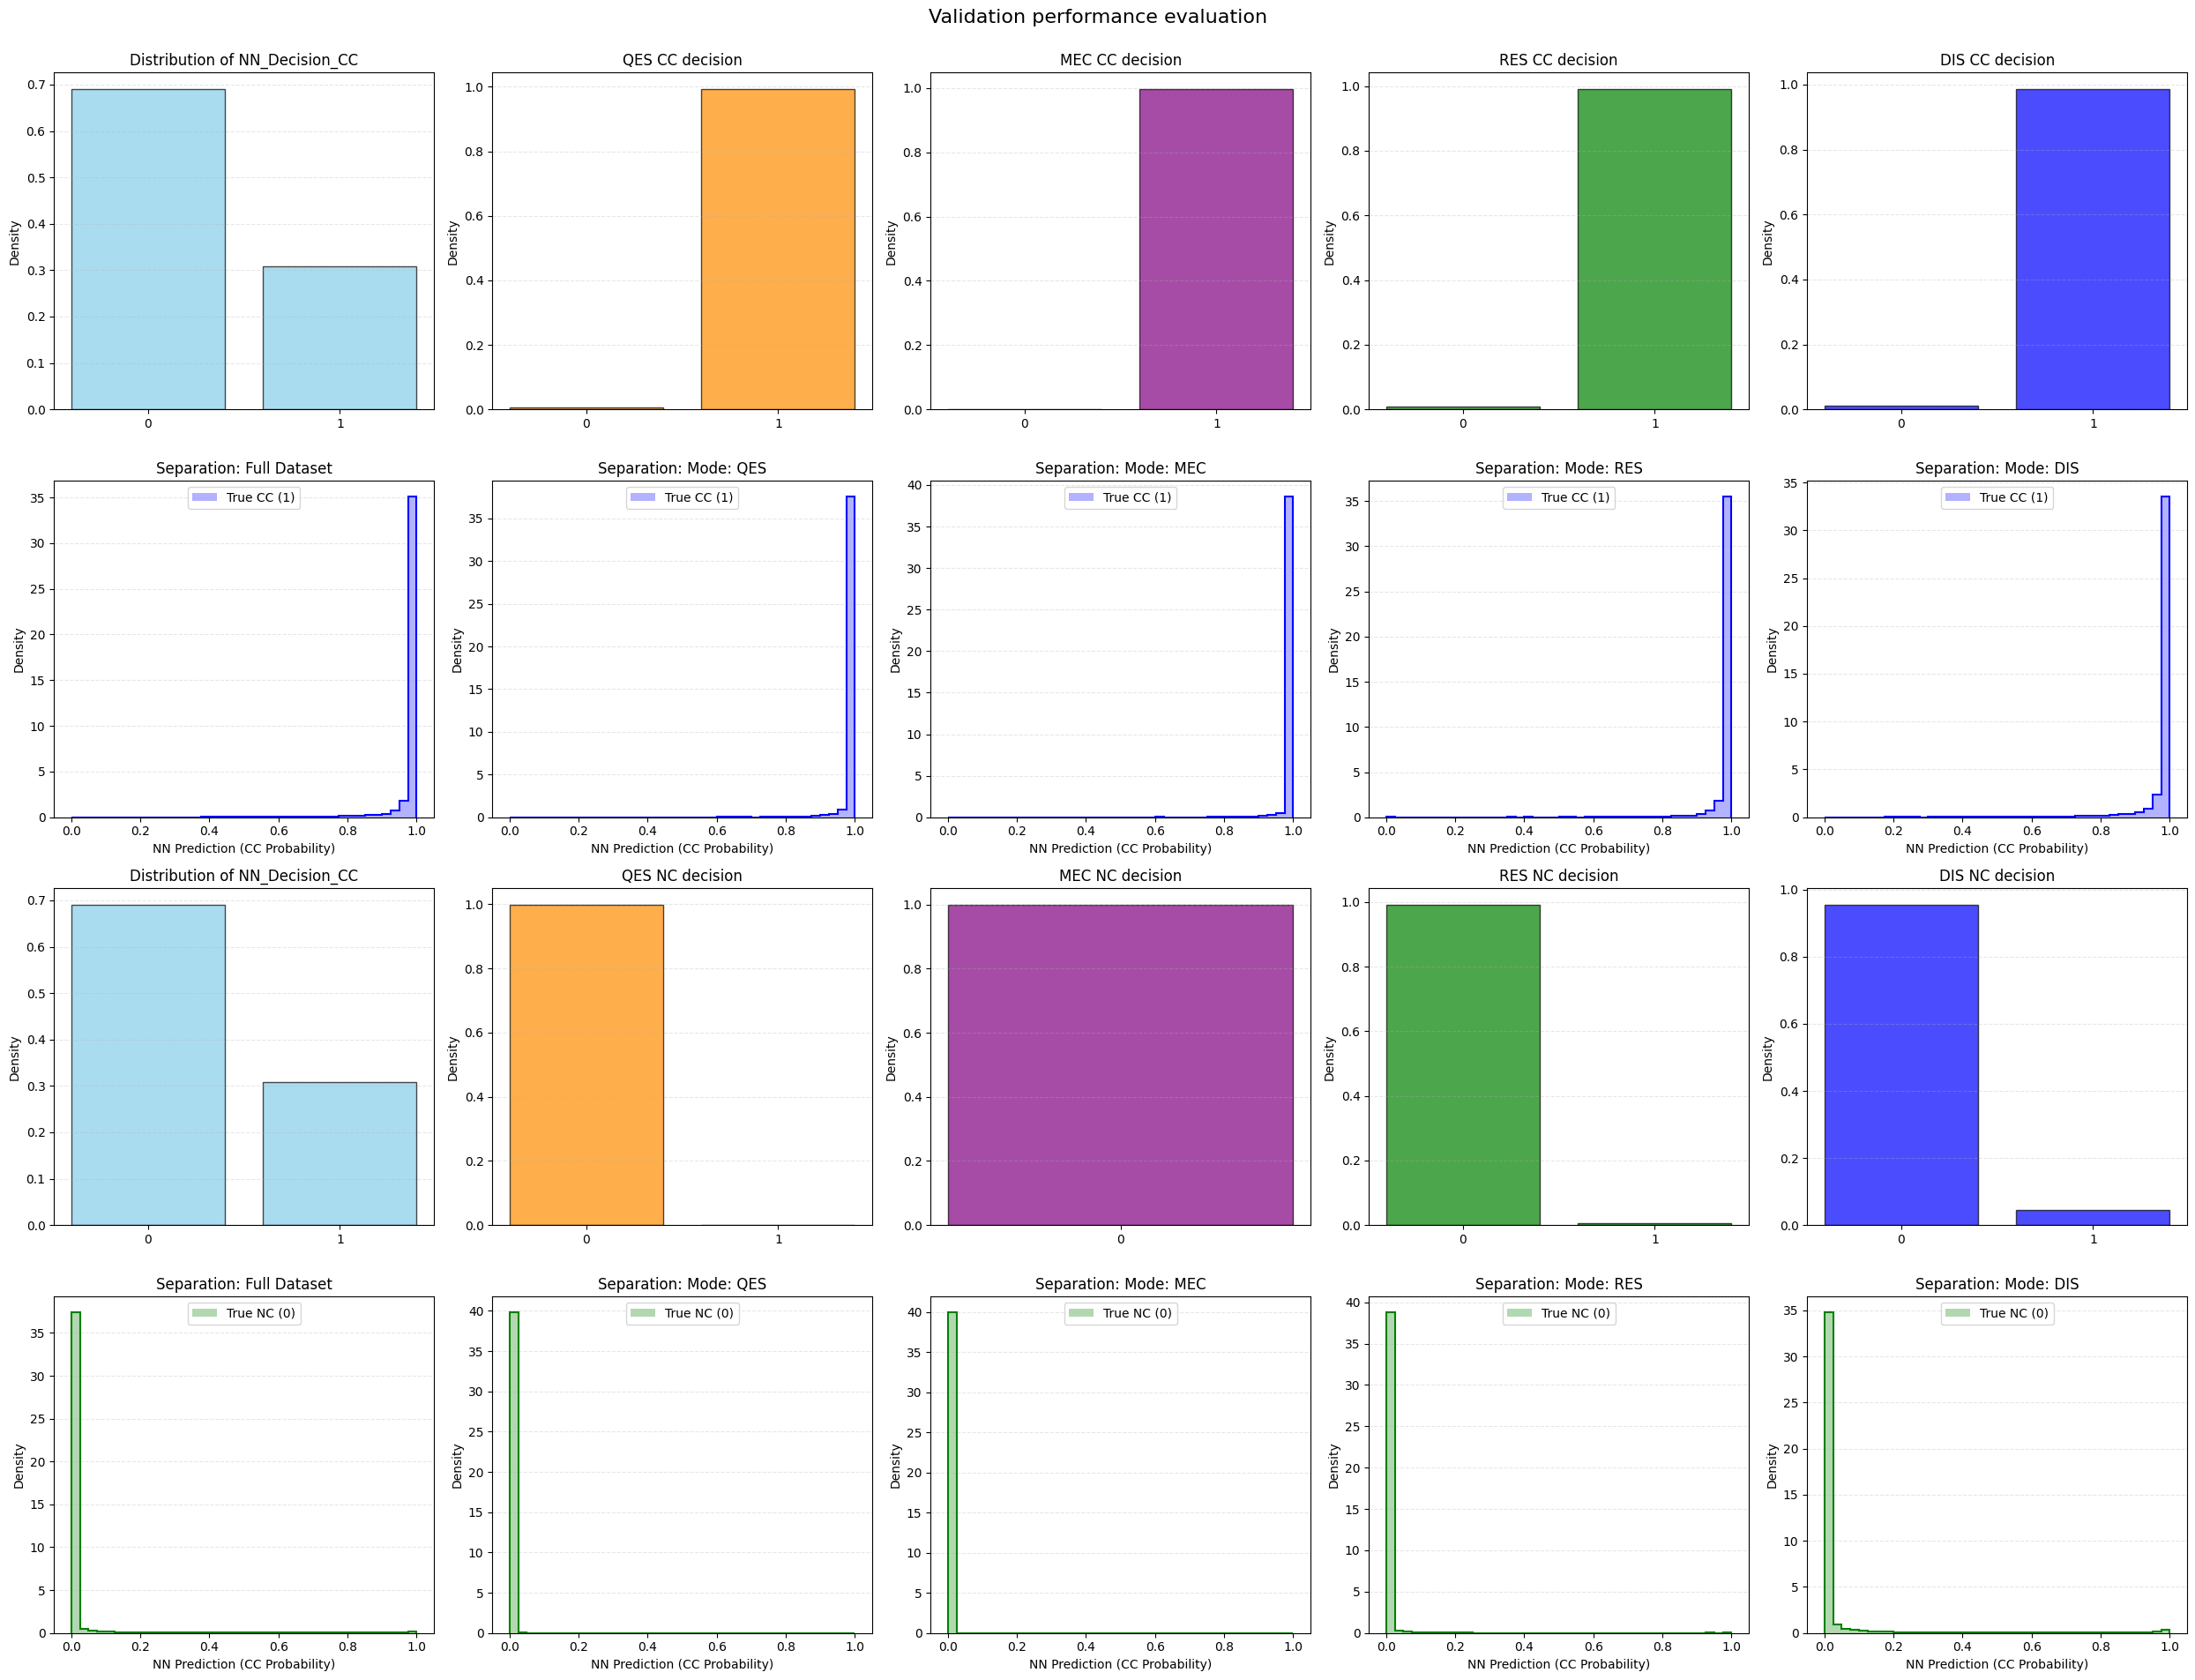

In [30]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

#training before after eval before after (4 cokumns), ccnn, int type (2 rows)
fig, axes = plt.subplots(4, 5, figsize=(25, 20))

plt.suptitle("Decision plots (1 is CC)", fontsize=16)

pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=1, int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
axes[0,1].set_title("QES CC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=1, int_filter='MEC', ax=axes[0,2], density=True, color='purple')
axes[0,2].set_title("MEC CC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=1, int_filter='RES', ax=axes[0,3], density=True, color='green')
axes[0,3].set_title("RES CC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=1, int_filter='DIS', ax=axes[0,4], density=True, color='blue')
axes[0,4].set_title("DIS CC decision")


pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter=None, ax=axes[1,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter='MEC', ax=axes[1,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter='RES', ax=axes[1,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter='DIS', ax=axes[1,4], density=True, color='blue')


pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=0, int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
axes[2,1].set_title("QES NC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=0, int_filter='MEC', ax=axes[2,2], density=True, color='purple')
axes[2,2].set_title("MEC NC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=0, int_filter='RES', ax=axes[2,3], density=True, color='green')
axes[2,3].set_title("RES NC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=0, int_filter='DIS', ax=axes[2,4], density=True, color='blue')
axes[2,4].set_title("DIS NC decision")


pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter=None, ax=axes[3,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter='MEC', ax=axes[3,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter='RES', ax=axes[3,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter='DIS', ax=axes[3,4], density=True, color='blue')

plt.suptitle("Validation performance evaluation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()



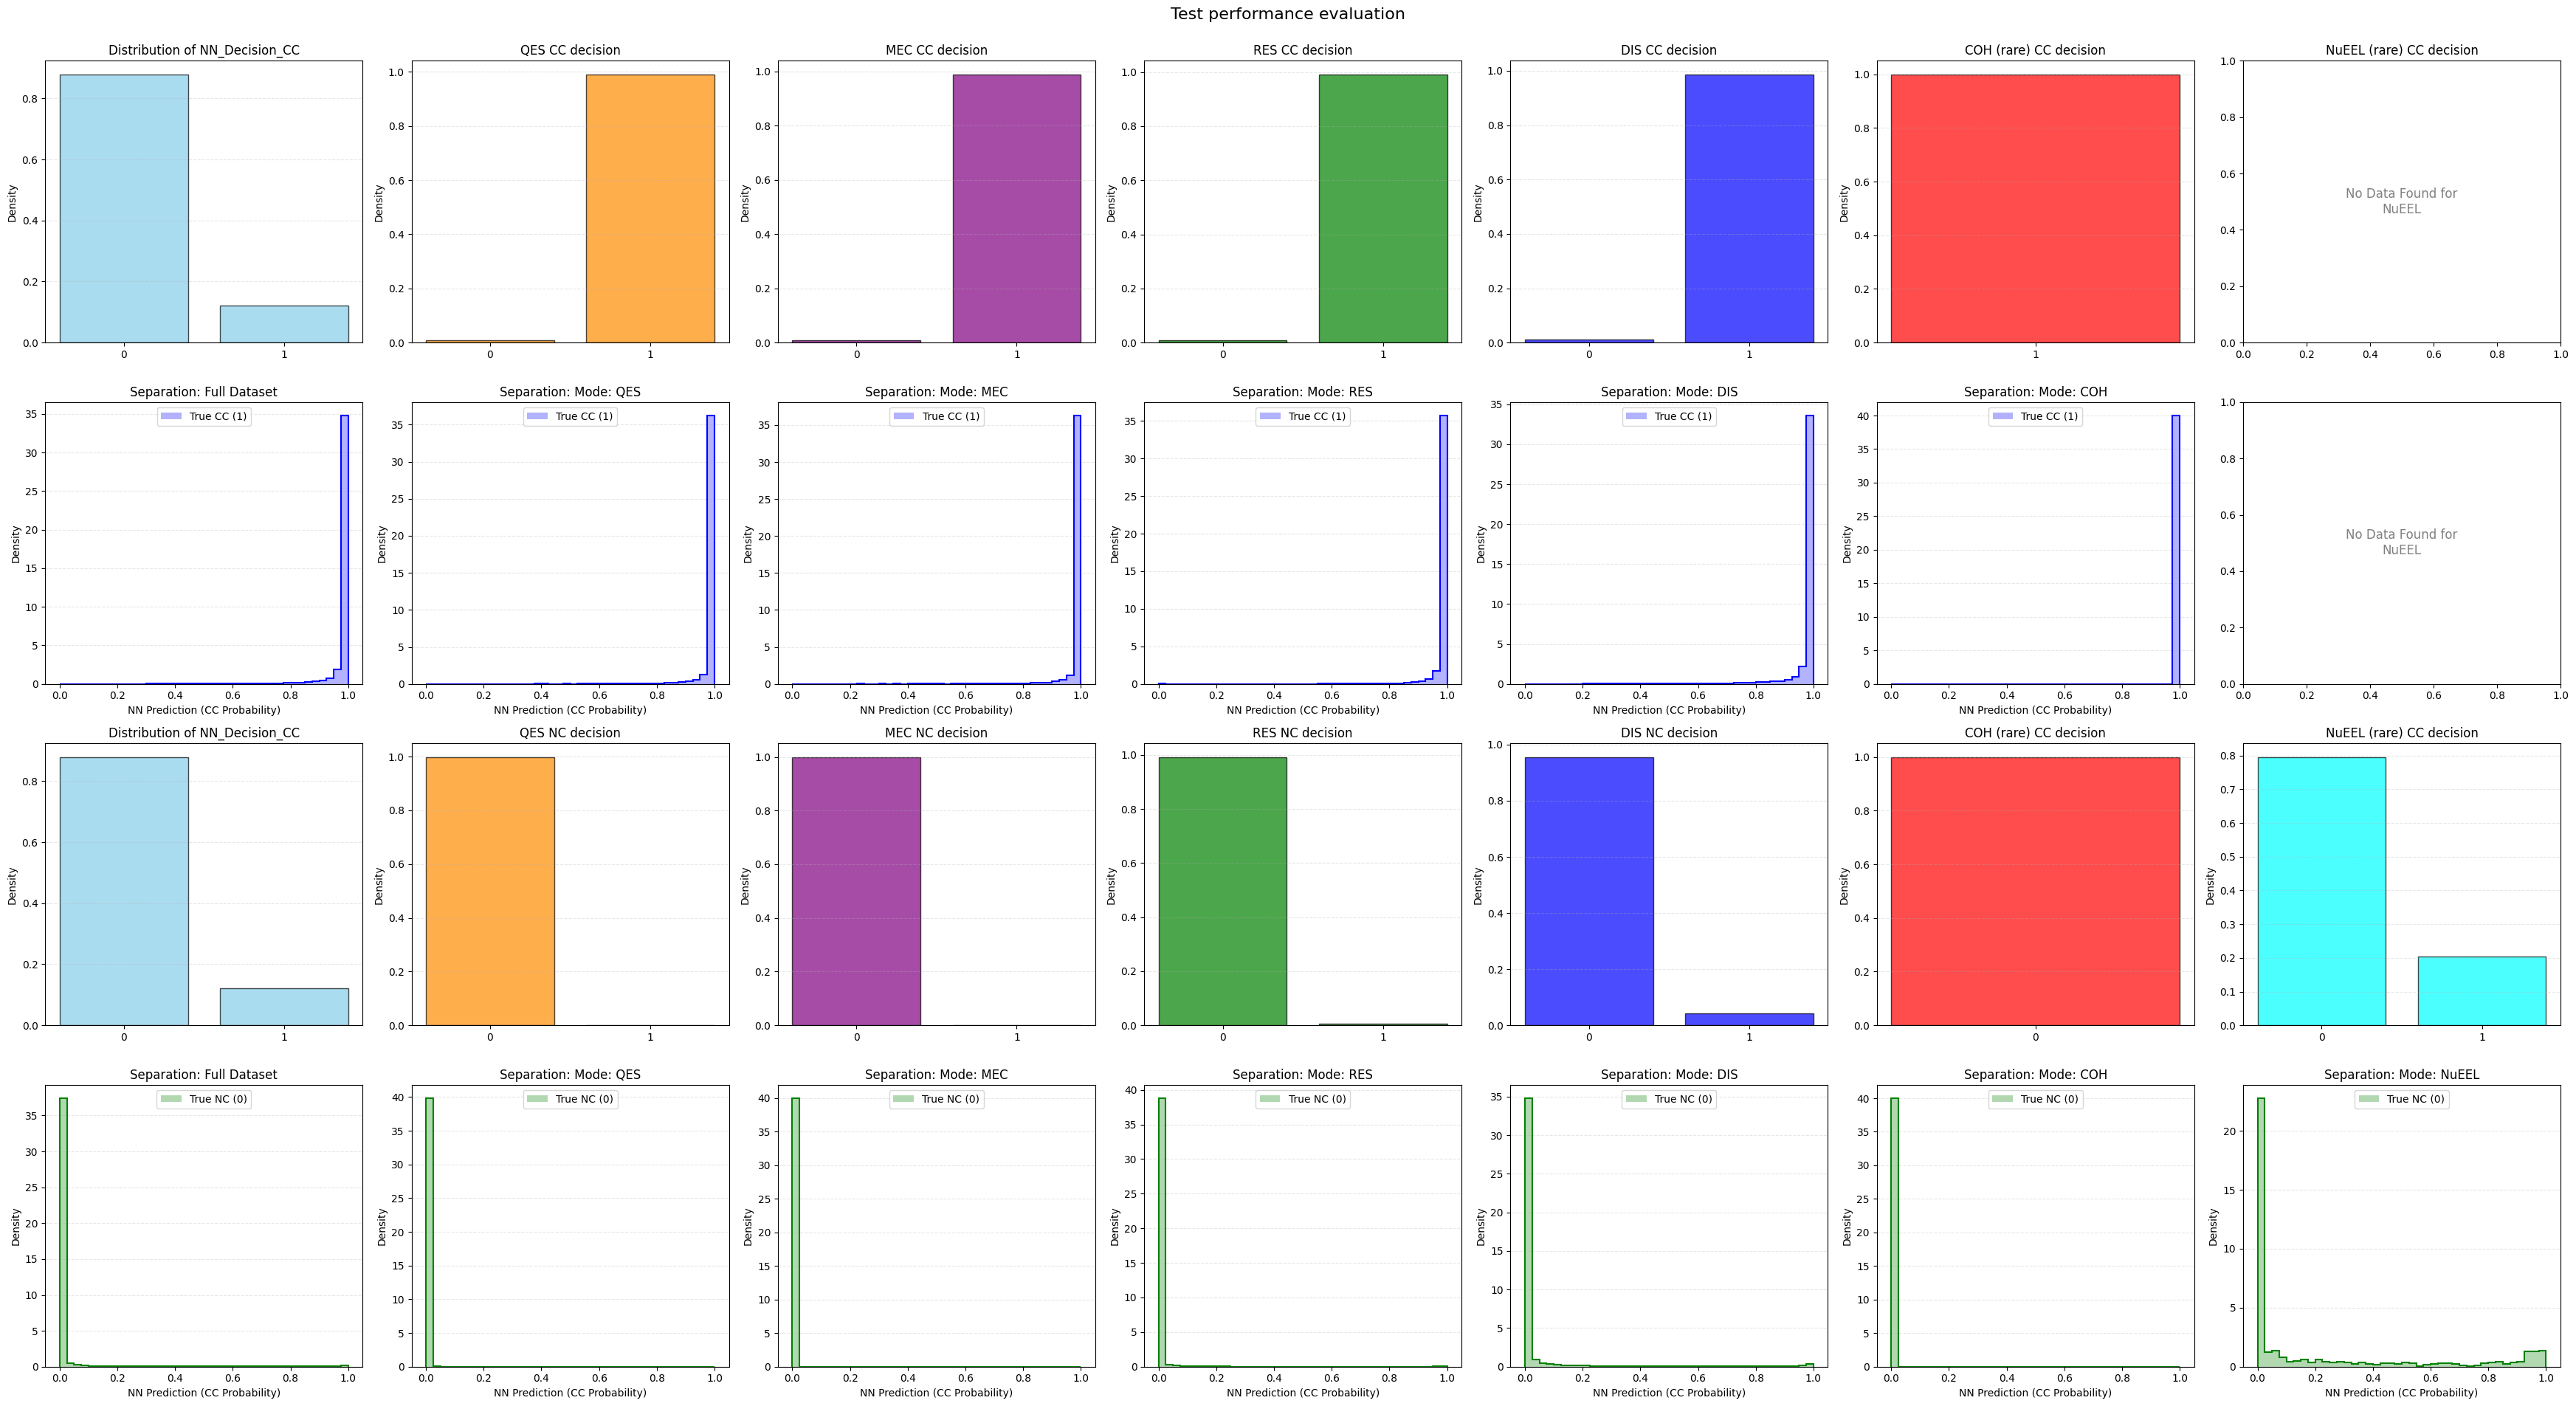

In [31]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

#training before after eval before after (4 cokumns), ccnn, int type (2 rows)
fig, axes = plt.subplots(4, 7, figsize=(35, 20))

plt.suptitle("Decision plots (1 is CC)", fontsize=16)
# (df_unbalanced_test, ['COH', 'NuEEL'])
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
axes[0,1].set_title("QES CC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='MEC', ax=axes[0,2], density=True, color='purple')
axes[0,2].set_title("MEC CC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='RES', ax=axes[0,3], density=True, color='green')
axes[0,3].set_title("RES CC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='DIS', ax=axes[0,4], density=True, color='blue')
axes[0,4].set_title("DIS CC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='COH', ax=axes[0,5], density=True, color='red')
axes[0,5].set_title("COH (rare) CC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='NuEEL', ax=axes[0,6], density=True, color='cyan')
axes[0,6].set_title("NuEEL (rare) CC decision")


pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter=None, ax=axes[1,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='MEC', ax=axes[1,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='RES', ax=axes[1,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='DIS', ax=axes[1,4], density=True, color='blue')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='COH', ax=axes[1,5], density=True, color='red')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='NuEEL', ax=axes[1,6], density=True, color='cyan')


pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
axes[2,1].set_title("QES NC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='MEC', ax=axes[2,2], density=True, color='purple')
axes[2,2].set_title("MEC NC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='RES', ax=axes[2,3], density=True, color='green')
axes[2,3].set_title("RES NC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='DIS', ax=axes[2,4], density=True, color='blue')
axes[2,4].set_title("DIS NC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='COH', ax=axes[2,5], density=True, color='red')
axes[2,5].set_title("COH (rare) CC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='NuEEL', ax=axes[2,6], density=True, color='cyan')
axes[2,6].set_title("NuEEL (rare) CC decision")


pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter=None, ax=axes[3,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='MEC', ax=axes[3,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='RES', ax=axes[3,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='DIS', ax=axes[3,4], density=True, color='blue')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='COH', ax=axes[3,5], density=True, color='red')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='NuEEL', ax=axes[3,6], density=True, color='cyan')

plt.suptitle("Test performance evaluation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()



Training PR AUC: 0.9990
Validation PR AUC: 0.9951
Test PR AUC: 0.9823


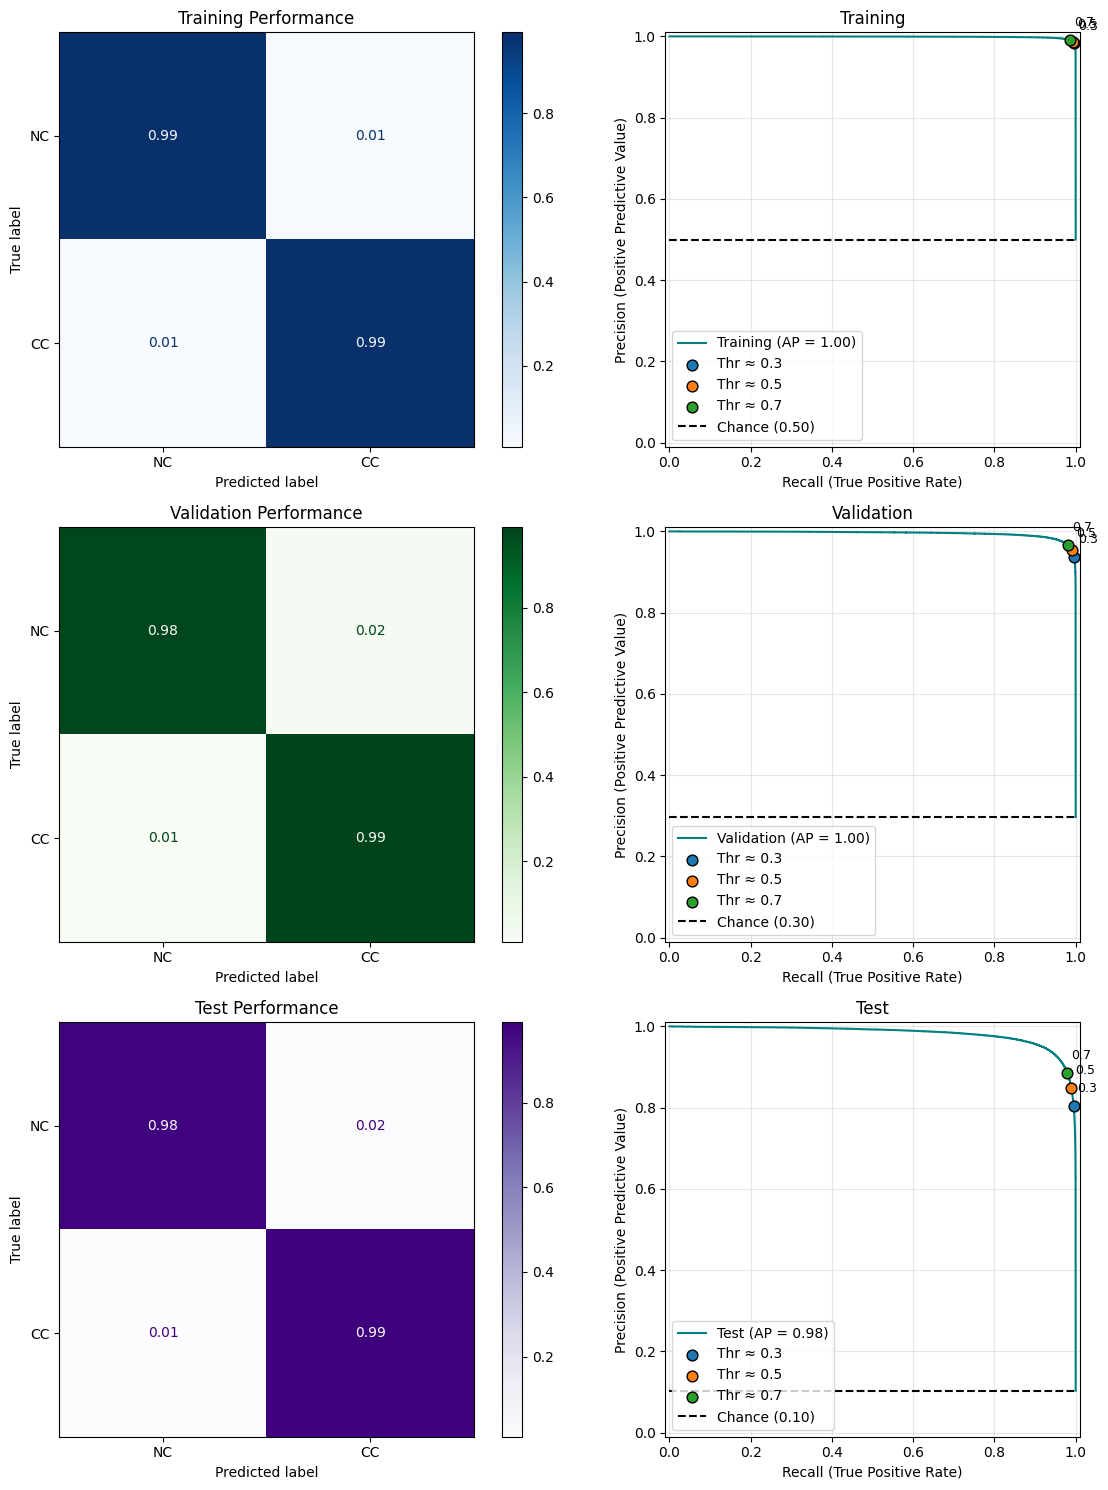

In [32]:
#CM and add metrics #plot auc
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

pf.plotConfusionMatrix(df_balanced_train, title="Training Performance", ax=axes[0,0], cmap='Blues')
pf.plotPRCurve(df_balanced_train, model_name="Training", ax=axes[0,1])
axes[0,1].set_title("Training")

pf.plotConfusionMatrix(df_unbalanced_val, title="Validation Performance", ax=axes[1,0], cmap='Greens')
pf.plotPRCurve(df_unbalanced_val, model_name="Validation", ax=axes[1,1])
axes[1,1].set_title("Validation")

pf.plotConfusionMatrix(df_unbalanced_test, title="Test Performance", ax=axes[2,0], cmap='Purples')
pf.plotPRCurve(df_unbalanced_test, model_name="Test", ax=axes[2,1])
axes[2,1].set_title("Test")

plt.tight_layout()
plt.show()

Training PR AUC: 0.9990
Validation PR AUC: 0.9951
Test PR AUC: 0.9823


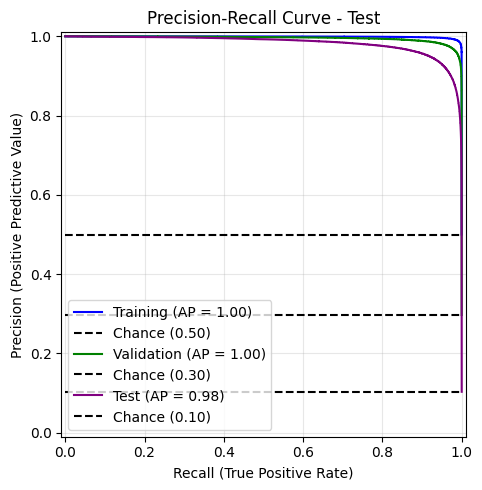

In [33]:
if full_plot:
    #CM and add metrics #plot auc
    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))


    pf.plotPRCurve(df_balanced_train, model_name="Training", ax=ax, color='blue', thresholds_to_plot=[])
    # axes[0,1].set_title("Training")


    pf.plotPRCurve(df_unbalanced_val, model_name="Validation", ax=ax, color='green', thresholds_to_plot=[])
    # axes[1,1].set_title("Validation")


    pf.plotPRCurve(df_unbalanced_test, model_name="Test", ax=ax, color='purple', thresholds_to_plot=[])
    # axes[2,1].set_title("Test")

    plt.tight_layout()
    plt.show()

Training ROC AUC: 0.9991
Validation ROC AUC: 0.9982
Test ROC AUC: 0.9981


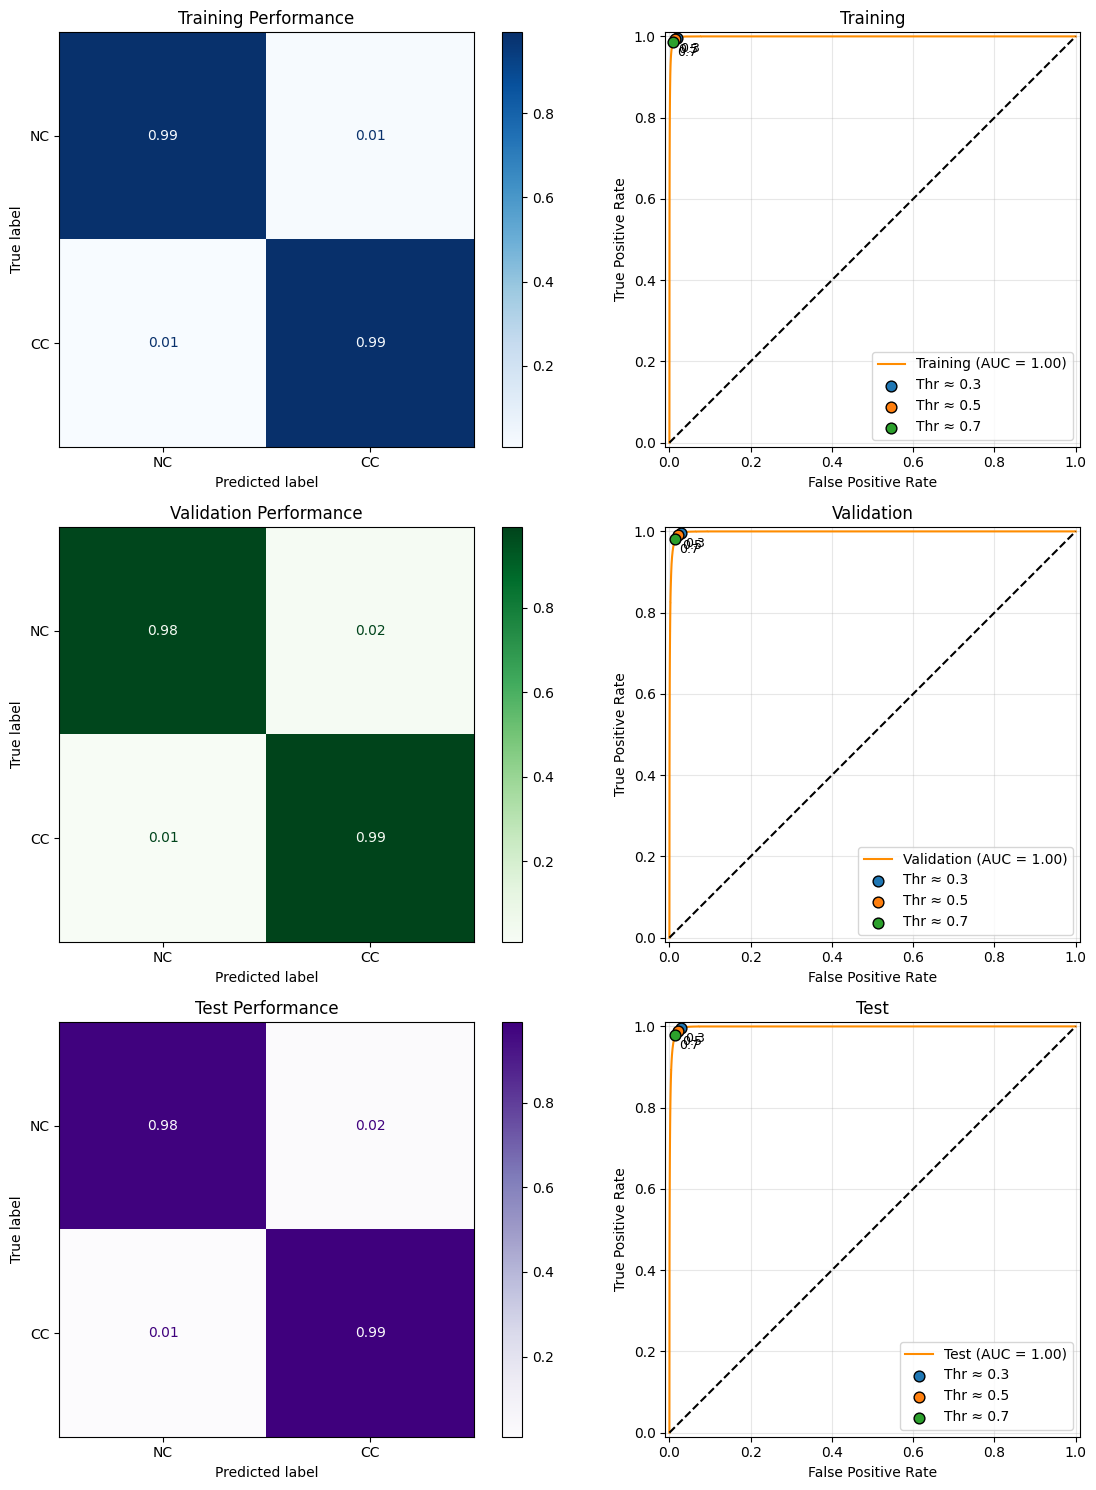

In [34]:
if full_plot:
    #CM and add metrics #plot auc
    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

    fig, axes = plt.subplots(3, 2, figsize=(12, 15))

    pf.plotConfusionMatrix(df_balanced_train, title="Training Performance", ax=axes[0,0], cmap='Blues')
    pf.plotROC(df_balanced_train, model_name="Training", ax=axes[0,1])
    axes[0,1].set_title("Training")

    pf.plotConfusionMatrix(df_unbalanced_val, title="Validation Performance", ax=axes[1,0], cmap='Greens')
    pf.plotROC(df_unbalanced_val, model_name="Validation", ax=axes[1,1])
    axes[1,1].set_title("Validation")

    pf.plotConfusionMatrix(df_unbalanced_test, title="Test Performance", ax=axes[2,0], cmap='Purples')
    pf.plotROC(df_unbalanced_test, model_name="Test", ax=axes[2,1])
    axes[2,1].set_title("Test")

    plt.tight_layout()
    plt.show()

Training ROC AUC: 0.9991
Validation ROC AUC: 0.9982
Test ROC AUC: 0.9981


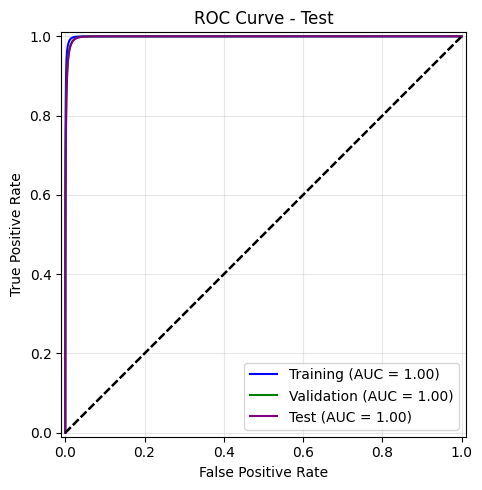

In [35]:
if full_plot:
    #CM and add metrics #plot auc
    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))


    pf.plotROC(df_balanced_train, model_name="Training", ax=ax, color='blue', thresholds_to_plot=[])
    # axes[0,1].set_title("Training")


    pf.plotROC(df_unbalanced_val, model_name="Validation", ax=ax, color='green', thresholds_to_plot=[])
    # axes[1,1].set_title("Validation")


    pf.plotROC(df_unbalanced_test, model_name="Test", ax=ax, color='purple', thresholds_to_plot=[])
    # axes[2,1].set_title("Test")

    plt.tight_layout()
    plt.show()

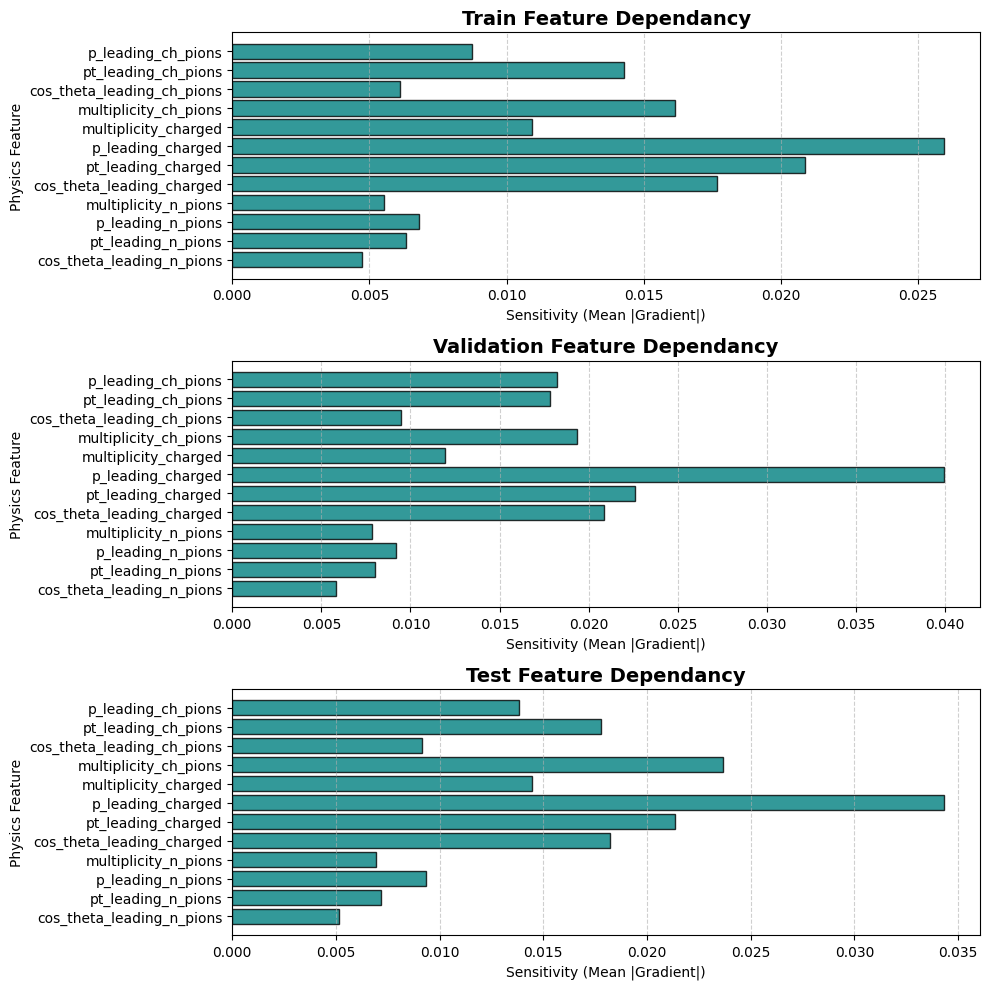

In [36]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

pf.plotFeatureImportance(model_1dCNN, train_data, title='Train Feature Dependancy', ax=axes[0])
pf.plotFeatureImportance(model_1dCNN, val_data, title='Validation Feature Dependancy',ax=axes[1])
pf.plotFeatureImportance(model_1dCNN, test_data, title='Test Feature Dependancy', ax=axes[2])

plt.tight_layout()
plt.show()

## Looking at outliners

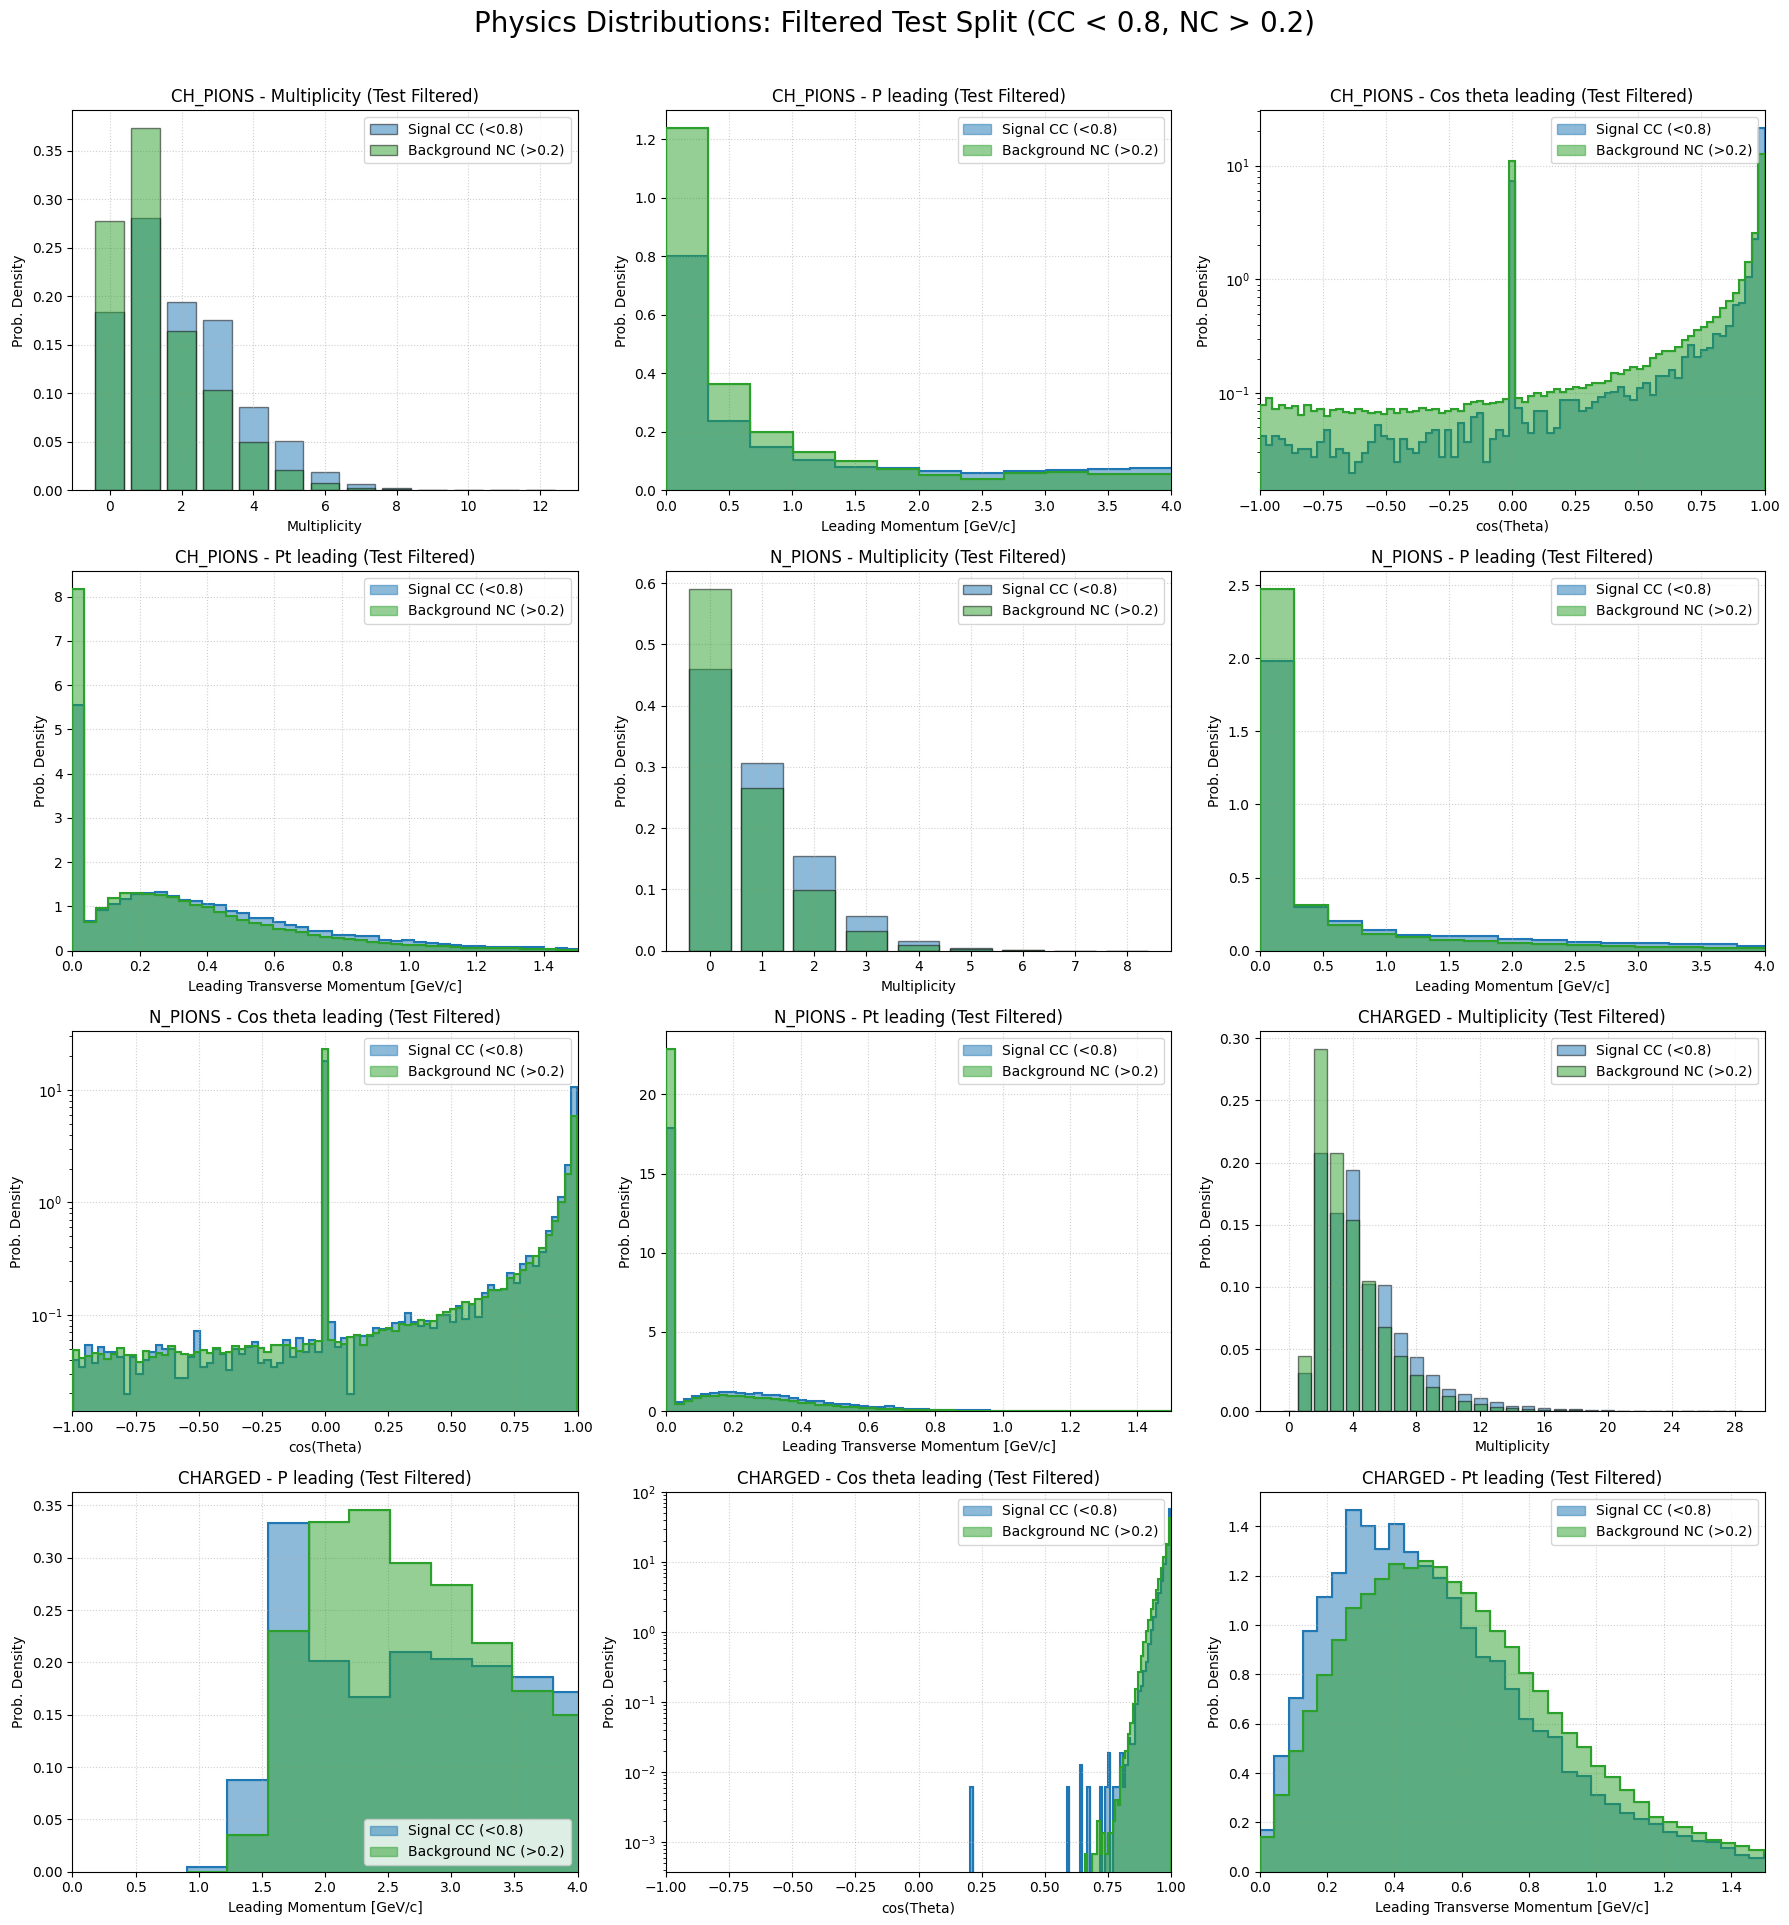

In [44]:
if full_plot:

    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

    # 1. Prepare your CC / NC splits for ONLY the Test set with probability conditions
    # CC: CCNC == 1 AND Prob_is_CC < 0.8
    df_test_CC = df_unbalanced_test[
        (df_unbalanced_test['CCNC'] == 1) & 
        (df_unbalanced_test['Prob_is_CC'] < 0.8)
    ]
    
    # NC: CCNC == 0 AND Prob_is_CC > 0.2
    df_test_NC = df_unbalanced_test[
        (df_unbalanced_test['CCNC'] == 0) & 
        (df_unbalanced_test['Prob_is_CC'] > 0.2)
    ]

    # 2. Define structural iterations
    modes = ['ch_pions', 'n_pions', 'charged']
    features = ['multiplicity', 'p_leading', 'cos_theta_leading', 'pt_leading']
    
    # Feature-specific plot tweaks 
    feature_configs = {
        'multiplicity':      {'xlim': None, 'log': False},
        'p_leading':         {'xlim': (0, 4), 'log': False},
        'pt_leading':        {'xlim': (0, 1.5), 'log': False},
        'cos_theta_leading': {'xlim': (-1, 1), 'log': True} 
    }

    # 3. Initialize the canvas
    # Swapped to a 4x3 grid (12 total plots) since we only have 1 column of data now
    fig, axes = plt.subplots(4, 3, figsize=(18, 20)) 
    
    # Flatten the 2D array of axes so we can easily iterate over it
    axes_flat = axes.flatten()
    
    plot_idx = 0
    for mode in modes:
        for feature in features:
            config = feature_configs[feature]
            ax = axes_flat[plot_idx]
            
            # Plot CC vs NC line for this specific block
            pf.plot_physics_single_canva(
                dfs=[df_test_CC, df_test_NC], 
                mode=mode, 
                feature=feature, 
                titles=["Signal CC (<0.8)", "Background NC (>0.2)"], 
                ax=ax, 
                density=True, 
                full_color_list=['#1f77b4', '#2ca02c'] 
            )
            
            # Apply custom configurations
            if config['xlim']:
                ax.set_xlim(config['xlim'])
            if config['log']:
                ax.set_yscale('log')
                
            # Append the dataset split name to the title
            ax.set_title(f"{ax.get_title()} (Test Filtered)")
            
            plot_idx += 1

    plt.suptitle(
        "Physics Distributions: Filtered Test Split (CC < 0.8, NC > 0.2)", 
        fontsize=20, 
        y=0.99
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

# Ensembles
Loading best performing models and taking their average probabilies which hopefully will results with just at least a slight increase in classification precision

In [51]:
train = 0
custom = 0

In [ ]:
#load any test data set to eval
if custom:
    output_path_demo = os.path.join(output_dir, 'data_all_tau_val.csv') #default gen, gtrack transformed and then initially preprocessed by /scratch1/gjedrzej/Lab/analysis/scripts/convert_full_nodebug.py
    df_demo = pd.read_csv(output_path_demo)
    df_demo = prf.get_feature_data(df_demo, ['ch_pions', 'n_pions', 'charged'], feature=['multiplicity', 'p_leading', 'pt_leading', 'theta_leading', 'cos_theta_leading'])
    df_demo = prf.clean_particle_data(df_demo)
    df_demo = prf.transform_ccnc(df_demo)
    df_demo = prf.fill_nans(df_demo)
    demo_data = prf.tensorize_data(df_demo, batch_size=1024)

In [52]:
if not train:
    #loading

    if custom:
        data = demo_data
        df_test = df_demo
    else: 
        data = test_data
        df_test = df_unbalanced_test

    nEpochsSaved = 150 

    predictions = []

    model_files = [
        "models/1DCNN-full-set-proto-fastLR.keras",
        "models/1DCNN_proto-with-x2-neurons.keras"
    ]
    for checkpoint_path in model_files:
        model = tf.keras.models.load_model(checkpoint_path.format(epoch=nEpochsSaved))
        
        # Predict and flatten to 1D array
        test_preds = model.predict(data).flatten()
        predictions.append(test_preds)

    ensemble_mean_preds = np.mean(predictions, axis=0)
    df_test['Prob_is_CC_ensemble'] = ensemble_mean_preds
    decision_threshold = 0.5

    # df_unbalanced_test['NN_Decision_CC_ensemble'] = (np.mean(predictions) > decision_threshold).astype(int)
    df_test['NN_Decision_CC_ensemble'] = (ensemble_mean_preds > decision_threshold).astype(int)
    

4846/4846 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step


Test PR AUC: 0.9819


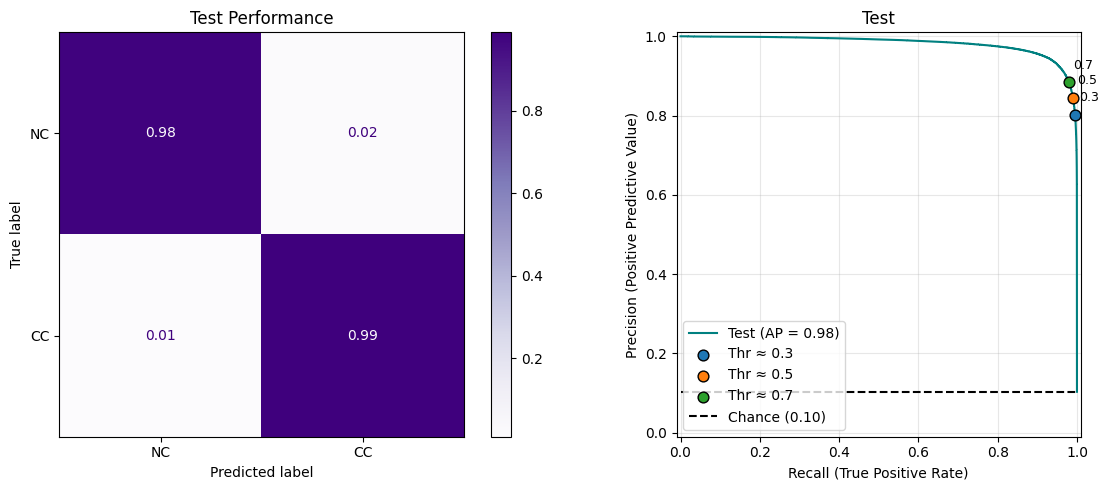

In [53]:
if not train:
    #CM and add metrics #plot auc
    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    pf.plotConfusionMatrix(df_test, pred_col='NN_Decision_CC_ensemble', title="Test Performance", ax=axes[0], cmap='Purples')
    pf.plotPRCurve(df_test, prob_col='Prob_is_CC_ensemble', model_name="Test", ax=axes[1])
    axes[1].set_title("Test")

    plt.tight_layout()
    plt.show()

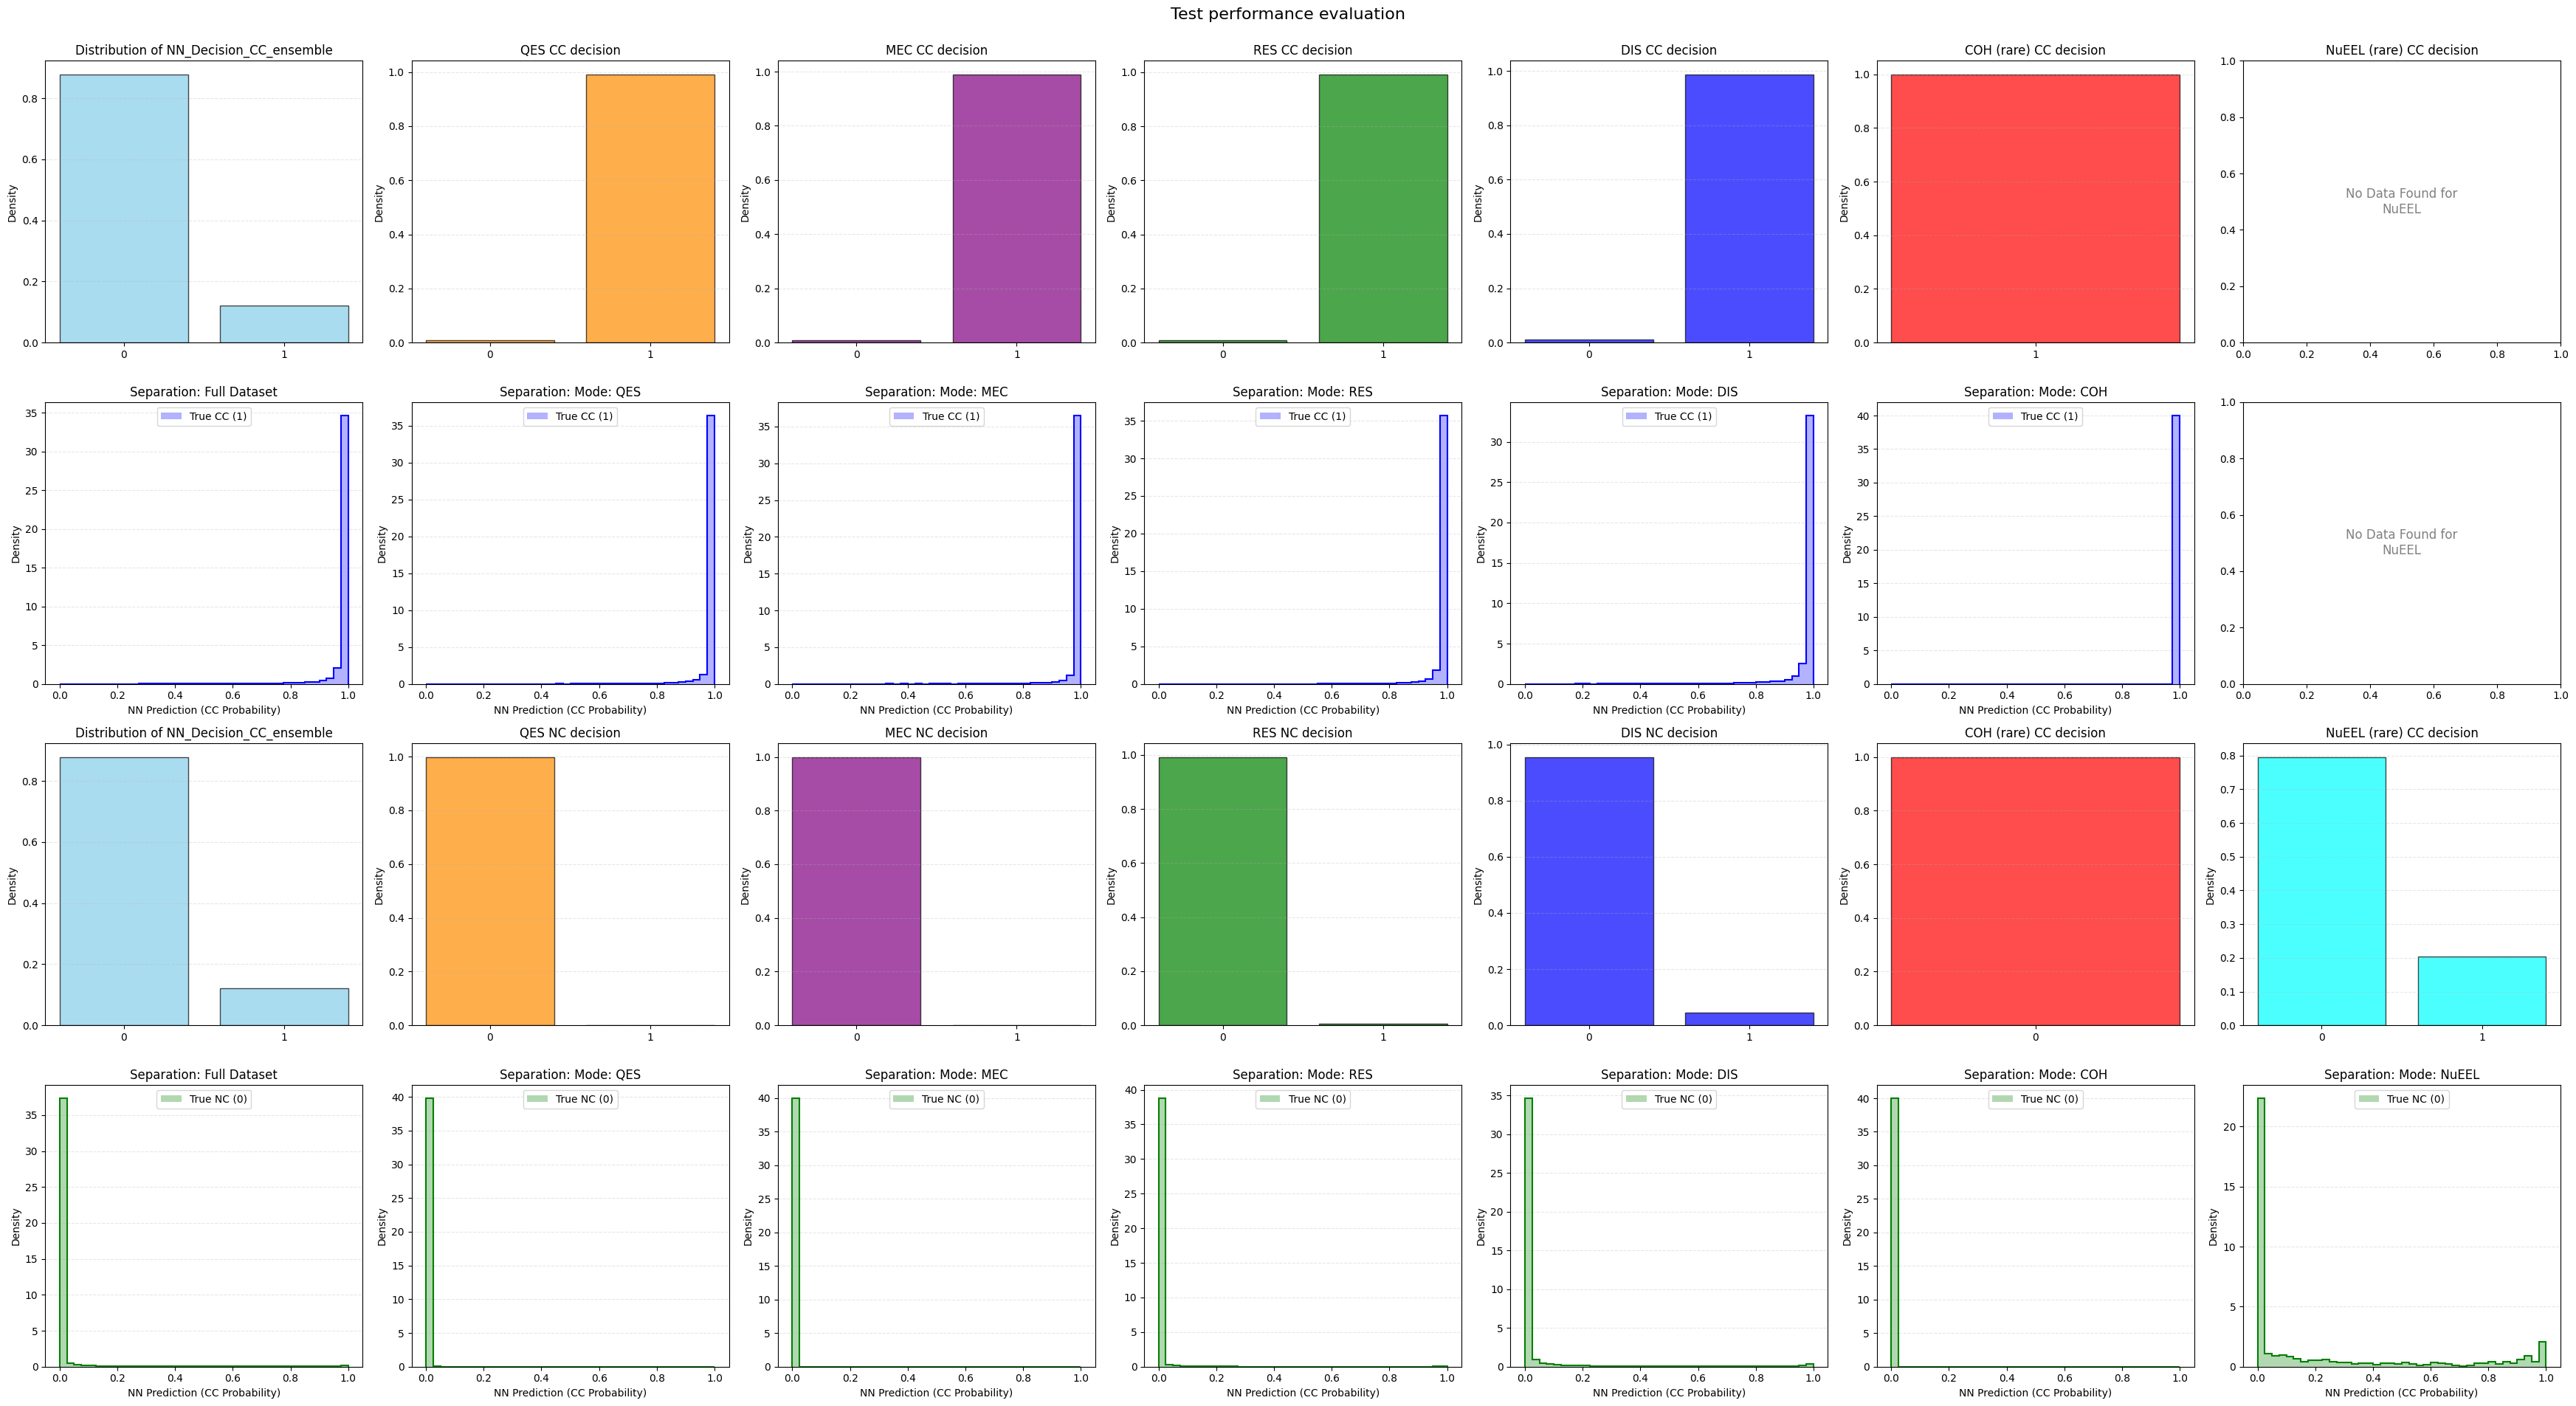

In [54]:
if not train:
    import analysis.scripts.plotting_functions as pf
    importlib.reload(pf)

    #training before after eval before after (4 cokumns), ccnn, int type (2 rows)
    fig, axes = plt.subplots(4, 7, figsize=(35, 20))

    plt.suptitle("Decision plots (1 is CC)", fontsize=16)
    # (df_unbalanced_test, ['COH', 'NuEEL'])
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=1, int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
    axes[0,1].set_title("QES CC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=1, int_filter='MEC', ax=axes[0,2], density=True, color='purple')
    axes[0,2].set_title("MEC CC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=1, int_filter='RES', ax=axes[0,3], density=True, color='green')
    axes[0,3].set_title("RES CC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=1, int_filter='DIS', ax=axes[0,4], density=True, color='blue')
    axes[0,4].set_title("DIS CC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=1, int_filter='COH', ax=axes[0,5], density=True, color='red')
    axes[0,5].set_title("COH (rare) CC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=1, int_filter='NuEEL', ax=axes[0,6], density=True, color='cyan')
    axes[0,6].set_title("NuEEL (rare) CC decision")


    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=1, int_filter=None, ax=axes[1,0], density=True, bins=None)
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=1, int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=1, int_filter='MEC', ax=axes[1,2], density=True, color='purple')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=1, int_filter='RES', ax=axes[1,3], density=True, color='green')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=1, int_filter='DIS', ax=axes[1,4], density=True, color='blue')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=1, int_filter='COH', ax=axes[1,5], density=True, color='red')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=1, int_filter='NuEEL', ax=axes[1,6], density=True, color='cyan')


    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=0, int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
    axes[2,1].set_title("QES NC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=0, int_filter='MEC', ax=axes[2,2], density=True, color='purple')
    axes[2,2].set_title("MEC NC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=0, int_filter='RES', ax=axes[2,3], density=True, color='green')
    axes[2,3].set_title("RES NC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=0, int_filter='DIS', ax=axes[2,4], density=True, color='blue')
    axes[2,4].set_title("DIS NC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=0, int_filter='COH', ax=axes[2,5], density=True, color='red')
    axes[2,5].set_title("COH (rare) CC decision")
    pf.plot_physics_results(df_test, column='NN_Decision_CC_ensemble', ccnc_filter=0, int_filter='NuEEL', ax=axes[2,6], density=True, color='cyan')
    axes[2,6].set_title("NuEEL (rare) CC decision")


    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=0, int_filter=None, ax=axes[3,0], density=True, bins=None)
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=0, int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=0, int_filter='MEC', ax=axes[3,2], density=True, color='purple')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=0, int_filter='RES', ax=axes[3,3], density=True, color='green')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=0, int_filter='DIS', ax=axes[3,4], density=True, color='blue')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=0, int_filter='COH', ax=axes[3,5], density=True, color='red')
    pf.plot_physics_results(df_test, column='Prob_is_CC_ensemble', ccnc_filter=0, int_filter='NuEEL', ax=axes[3,6], density=True, color='cyan')

    plt.suptitle("Test performance evaluation", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    # rect=[left, bottom, right, top] in normalized 0-1 coordinates
    plt.show()

